In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("financial_distress_modelling.csv")

print(df.shape)
df.head()
df.info()

(3957, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ticker            3957 non-null   object 
 1   Year              3957 non-null   int64  
 2   Borrowings        3957 non-null   float64
 3   CFO               3957 non-null   float64
 4   CWIP              3957 non-null   float64
 5   Depreciation      3957 non-null   float64
 6   EquityCapital     3957 non-null   float64
 7   FCF               3957 non-null   float64
 8   FixedAssets       3957 non-null   float64
 9   Interest          3957 non-null   float64
 10  Investments       3957 non-null   float64
 11  NetProfit         3957 non-null   float64
 12  OperatingProfit   3957 non-null   float64
 13  OtherAssets       3957 non-null   float64
 14  OtherLiabilities  3957 non-null   float64
 15  PBT               3957 non-null   float64
 16  Reserves          3957 non-null

In [3]:
df.isnull().sum().sort_values(ascending=False)
df.duplicated().sum()
df["FutureDistress"].value_counts()

,count
FutureDistress,
0,3744
1,213


## Feature Selection

In [4]:
# ============================================================
# FILTER 1: Domain Knowledge Filter
# Remove identifiers and target leakage variables
# ============================================================

drop_filter1 = [
    # Identifier
    "Ticker",

    # Target
    "FutureDistress",
    "CurrentDistress",

    # Variables created solely for label construction
    "SectorThreshold"
]

X = df.drop(columns=drop_filter1)

# Target variable
y = df["FutureDistress"]

print(f"Number of features after Filter 1: {X.shape[1]}")
print("\nRemaining Features:")
print(X.columns.tolist())



Number of features after Filter 1: 35

Remaining Features:
['Year', 'Borrowings', 'CFO', 'CWIP', 'Depreciation', 'EquityCapital', 'FCF', 'FixedAssets', 'Interest', 'Investments', 'NetProfit', 'OperatingProfit', 'OtherAssets', 'OtherLiabilities', 'PBT', 'Reserves', 'Sales', 'TotalAssets', 'TotalLiabilities', 'Equity', 'Sector', 'DebtAssets', 'InterestCoverage', 'ROA', 'ROE', 'OperatingMargin', 'NetMargin', 'DebtEquity', 'EquityRatio', 'CFOtoAssets', 'FCFtoAssets', 'AssetTurnover', 'FixedAssetRatio', 'CWIPRatio', 'InvestmentRatio']


## Train-Test-Split

In [5]:
df.groupby("Year").agg(
    Observations=("FutureDistress", "size"),
    Distressed=("FutureDistress", "sum")
)

,Observations,Distressed
Year,,
2005,1,0
2006,3,0
2007,4,0
2008,4,1
2009,6,1
2010,5,1
2011,6,0
2012,6,1
2013,6,0


In [6]:
company_years = (
    df.groupby("Ticker")
      .size()
)

print(company_years.describe())

print(
    company_years.value_counts()
                 .sort_index()
)

count    415.000000
mean       9.534940
std        2.510482
min        1.000000
25%        8.000000
50%       11.000000
75%       11.000000
max       12.000000
dtype: float64
1       3
2       5
3      12
4       9
5       8
6      26
7      23
8      22
9      17
10      9
11    276
12      5
Name: count, dtype: int64


In [7]:
year_stats = (
    df.groupby("Year")["FutureDistress"]
    .agg(["count", "sum"])
)

year_stats["DistressRate"] = (
    year_stats["sum"] / year_stats["count"]
)

year_stats

,count,sum,DistressRate
Year,,,
2005,1,0,0.000000
2006,3,0,0.000000
2007,4,0,0.000000
2008,4,1,0.250000
2009,6,1,0.166667
2010,5,1,0.200000
2011,6,0,0.000000
2012,6,1,0.166667
2013,6,0,0.000000


### **Cut-Off Year : `2023`** (to get 70/30 split approx)

In [8]:
# ==========================================================
# Time-Based Train-Test Split
# ==========================================================

split_year = 2023

X_train = X[X["Year"] < split_year].copy()
X_test = X[X["Year"] >= split_year].copy()

y_train = y[X["Year"] < split_year].copy()
y_test = y[X["Year"] >= split_year].copy()

In [9]:
print("=" * 50)
print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

print("\nTraining Years :", sorted(X_train["Year"].unique()))
print("Testing Years  :", sorted(X_test["Year"].unique()))

Training Set Shape : (2746, 35)
Testing Set Shape  : (1211, 35)

Training Years : [np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Testing Years  : [np.int64(2023), np.int64(2024), np.int64(2025)]


In [10]:
print("=" * 50)
print("Training Set")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Set
FutureDistress
0    2588
1     158
Name: count, dtype: int64
FutureDistress
0    94.25
1     5.75
Name: proportion, dtype: float64

Testing Set
FutureDistress
0    1156
1      55
Name: count, dtype: int64
FutureDistress
0    95.46
1     4.54
Name: proportion, dtype: float64


In [11]:
X_train["Year"].sample(5)

,Year
1169,2016
14,2015
2347,2018
1848,2015
2470,2015


Mann–Whitney U → Is this variable individually discriminative?

In [12]:
from scipy.stats import mannwhitneyu

check_vars = [
    "DebtAssets",
    "InterestCoverage",
    "Equity"
]

results = []

for col in check_vars:
    healthy = X_train.loc[y_train == 0, col].dropna()
    distressed = X_train.loc[y_train == 1, col].dropna()

    stat, p = mannwhitneyu(
        healthy,
        distressed,
        alternative="two-sided"
    )

    results.append({
        "Variable": col,
        "HealthyMedian": healthy.median(),
        "DistressedMedian": distressed.median(),
        "PValue": p
    })

pd.DataFrame(results).sort_values("PValue")

,Variable,HealthyMedian,DistressedMedian,PValue
1,InterestCoverage,8.598913,0.006452,1.989429e-79
0,DebtAssets,0.182879,0.438806,8.132478e-17
2,Equity,2706.055000,1335.000000,1.716031e-11


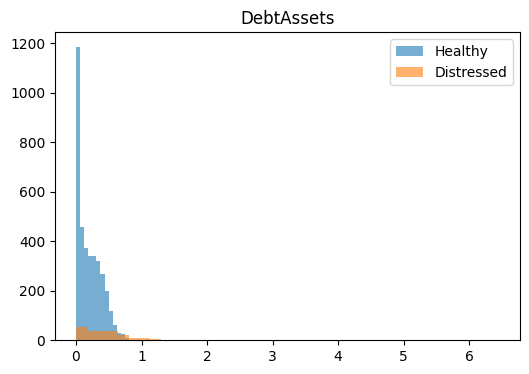

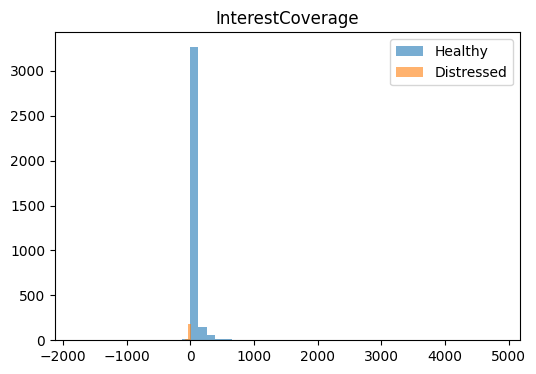

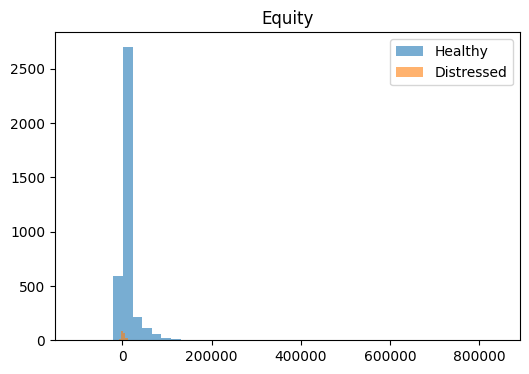

In [13]:
import matplotlib.pyplot as plt

vars_to_plot = [
    "DebtAssets",
    "InterestCoverage",
    "Equity"
]

for col in vars_to_plot:
    plt.figure(figsize=(6,4))

    plt.hist(
        df[df["FutureDistress"]==0][col],
        bins=40,
        alpha=0.6,
        label="Healthy"
    )

    plt.hist(
        df[df["FutureDistress"]==1][col],
        bins=40,
        alpha=0.6,
        label="Distressed"
    )

    plt.title(col)
    plt.legend()
    plt.show()

In [14]:
from sklearn.metrics import roc_auc_score

variables = [
    "DebtAssets",
    "InterestCoverage",
    "Equity"
]

for col in variables:

    temp = df[[col, "FutureDistress"]].dropna()

    auc = roc_auc_score(
        temp["FutureDistress"],
        temp[col]
    )

    print(f"{col}: AUC = {auc:.3f}")

DebtAssets: AUC = 0.715
InterestCoverage: AUC = 0.044
Equity: AUC = 0.341


In [15]:
# Rule 1
pd.crosstab(df["FutureDistress"], df["Equity"] <= 0)

# Rule 2
pd.crosstab(df["FutureDistress"], df["InterestCoverage"] < 1)

# Rule 3
pd.crosstab(
    df["FutureDistress"],
    df["DebtAssets"] > df["SectorThreshold"]
)

col_0,False,True
FutureDistress,,
0,3403,341
1,113,100


We won't remove "DebtAssets", "InterestCoverage", "Equity"due to label leakage now

In [16]:
# ==========================================================
# FEATURE SELECTION TRACKER
# ==========================================================

selected_features = []
removed_features = {}

In [17]:
# ============================================================
# FILTER 2: Statistical Knowledge Filter
# ============================================================

1. Profitability

    *Raw Variables* :
    NetProfit,
    PBT,
    OperatingProfit

    *Engineered Variables* :
    ROA,
    ROE,
    NetMargin,
    OperatingMargin

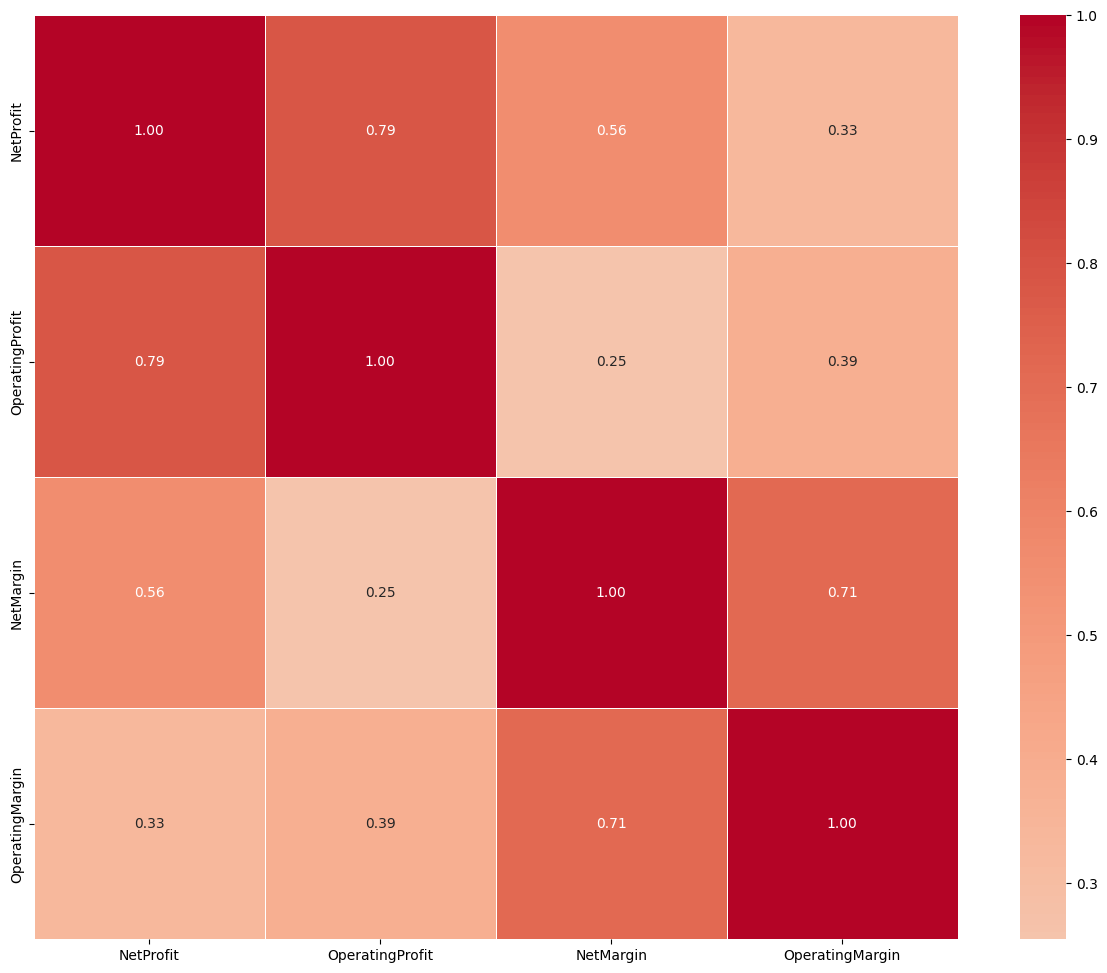

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

opr = ["NetProfit",
    "OperatingProfit",
    "NetMargin",
    "OperatingMargin"
]
corr = X_train[opr].corr(method="spearman")

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f"
)

plt.show()

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

opr = ["NetProfit",
    "OperatingProfit",
    "NetMargin",
    "OperatingMargin"
]

X = X_train[opr].dropna()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF":[
        variance_inflation_factor(X.values,i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF",ascending=False)

,Variable,VIF
2,NetMargin,105.996117
3,OperatingMargin,105.957502
0,NetProfit,2.593577
1,OperatingProfit,2.577628


In [20]:
# ==========================================================
# FILTER 2.1 : PROFITABILITY
# ==========================================================

# Selected features
selected_profitability = [
    "NetProfit",
    "OperatingProfit",
    "ROA",
]

# Removed features
removed_profitability = [
    "PBT",
    "ROE",
    "NetMargin",
    "OperatingMargin"
]

# Update master lists
selected_features.extend(selected_profitability)
removed_features["Profitability"] = removed_profitability

# Display
print("Selected Profitability Features:")
print(selected_profitability)

print("\nRemoved Profitability Features:")
print(removed_profitability)

Selected Profitability Features:
['NetProfit', 'OperatingProfit', 'ROA']

Removed Profitability Features:
['PBT', 'ROE', 'NetMargin', 'OperatingMargin']


2. Cash Flow

    Raw:
    CFO,
    FCF

    Engineered:
    CFOtoAssets,
    FCFtoAssets

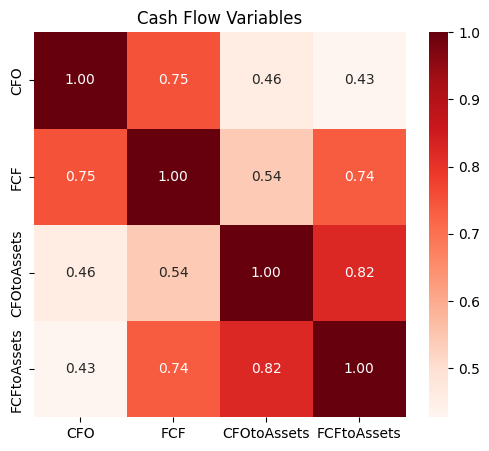

In [21]:
cashflow = [
    "CFO",
    "FCF",
    "CFOtoAssets",
    "FCFtoAssets"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    X_train[cashflow].corr(method="spearman"),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Cash Flow Variables")
plt.show()

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cashflow = [
    "CFO",
    "FCF",
    "CFOtoAssets",
    "FCFtoAssets"
]

X = X_train[cashflow].dropna()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF":[
        variance_inflation_factor(X.values,i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF",ascending=False)

,Variable,VIF
3,FCFtoAssets,10.588117
2,CFOtoAssets,10.372411
1,FCF,1.698792
0,CFO,1.557338


In [23]:
from scipy.stats import mannwhitneyu

results=[]

for col in cashflow:

    healthy = X_train.loc[y_train == 0, col].dropna()
    distressed = X_train.loc[y_train == 1, col].dropna()

    stat,p = mannwhitneyu(
        healthy,
        distressed,
        alternative="two-sided"
    )

    results.append({
        "Variable":col,
        "HealthyMedian":healthy.median(),
        "DistressedMedian":distressed.median(),
        "PValue":p
    })

pd.DataFrame(results).sort_values("PValue")

,Variable,HealthyMedian,DistressedMedian,PValue
2,CFOtoAssets,0.098342,0.002124,3.472137e-33
3,FCFtoAssets,0.049335,-0.028027,9.205001e-24
0,CFO,511.000000,6.000000,7.152352e-22
1,FCF,221.000000,-159.500000,1.446112e-20


In [24]:
# ==========================================================
# FILTER 2.2 : CASH FLOW
# ==========================================================

# Selected features
selected_cashflow = [
    "CFO",
    "FCF",
    "CFOtoAssets"
]

# Removed features
removed_cashflow = [
    "FCFtoAssets"
]

# Update master lists
selected_features.extend(selected_cashflow)
removed_features["Cash Flow"] = removed_cashflow

# Display
print("Selected Cash Flow Features:")
print(selected_cashflow)

print("\nRemoved Cash Flow Features:")
print(removed_cashflow)

Selected Cash Flow Features:
['CFO', 'FCF', 'CFOtoAssets']

Removed Cash Flow Features:
['FCFtoAssets']


- FCFtoAssets was removed because it exhibited high multicollinearity with CFOtoAssets (Spearman correlation = 0.82; VIF = 8.58) while representing a similar financial concept.

3. Leverage & Capital Structure

    Raw :
    Borrowings,
    Interest,
    Equity,
    TotalAssets

    Engineered :
    DebtAssets,
    DebtEquity,
    EquityRatio,
    InterestCoverage

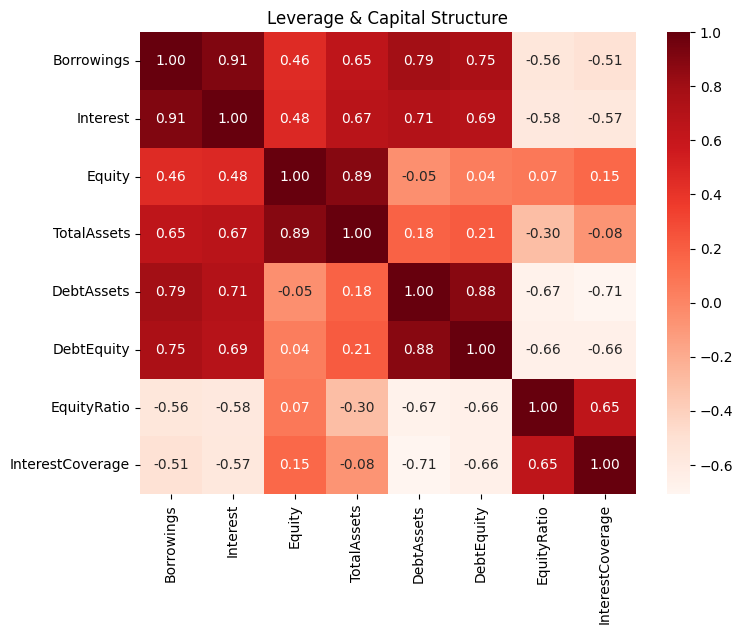

In [25]:
leverage = [
    "Borrowings",
    "Interest",
    "Equity",
    "TotalAssets",
    "DebtAssets",
    "DebtEquity",
    "EquityRatio",
    "InterestCoverage"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    X_train[leverage].corr(method="spearman"),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Leverage & Capital Structure")
plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X_train[leverage].dropna()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF":[
        variance_inflation_factor(X.values,i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF",ascending=False)

,Variable,VIF
3,TotalAssets,44.333442
0,Borrowings,21.061343
2,Equity,18.067197
1,Interest,9.210821
4,DebtAssets,1.399500
6,EquityRatio,1.337329
7,InterestCoverage,1.118817
5,DebtEquity,1.032814


In [27]:
from scipy.stats import mannwhitneyu

results=[]

for col in leverage:

    healthy = X_train.loc[y_train == 0, col].dropna()
    distressed = X_train.loc[y_train == 1, col].dropna()

    stat,p = mannwhitneyu(
        healthy,
        distressed,
        alternative="two-sided"
    )

    results.append({
        "Variable":col,
        "HealthyMedian":healthy.median(),
        "DistressedMedian":distressed.median(),
        "PValue":p
    })

pd.DataFrame(results).sort_values("PValue")

,Variable,HealthyMedian,DistressedMedian,PValue
7,InterestCoverage,8.598913,0.006452,1.989429e-79
6,EquityRatio,0.493677,0.240608,2.508218e-21
4,DebtAssets,0.182879,0.438806,8.132478e-17
2,Equity,2706.055000,1335.000000,1.716031e-11
0,Borrowings,685.500000,2178.500000,1.299884e-06
1,Interest,55.000000,156.500000,5.261269e-06
3,TotalAssets,6086.500000,7547.000000,3.803431e-01
5,DebtEquity,0.362251,0.388649,6.079861e-01


In [28]:
# ==========================================================
# FILTER 2.3 : LEVERAGE & CAPITAL STRUCTURE
# ==========================================================

# Selected features
selected_leverage = [
    "Interest",
    "DebtAssets",
    "EquityRatio",
    "InterestCoverage"
]

# Removed features
removed_leverage = [
    "Borrowings",
    "Equity",
    "TotalAssets",
    "DebtEquity"
]

# Update master lists
selected_features.extend(selected_leverage)
removed_features["Leverage & Capital Structure"] = removed_leverage

# Display
print("Selected Leverage Features:")
print(selected_leverage)

print("\nRemoved Leverage Features:")
print(removed_leverage)

Selected Leverage Features:
['Interest', 'DebtAssets', 'EquityRatio', 'InterestCoverage']

Removed Leverage Features:
['Borrowings', 'Equity', 'TotalAssets', 'DebtEquity']


- Borrowings (High VIF)
- Equity (High VIF)
- TotalAssets (High VIF)
- DebtEquity (Not Significant)

these were removed

4. Asset Structure & Investment

    Raw :
    CWIP,
    FixedAssets,
    Investments,
    OtherAssets,
    Depreciation

    Engineered :
    FixedAssetRatio,
    CWIPRatio,
    InvestmentRatio


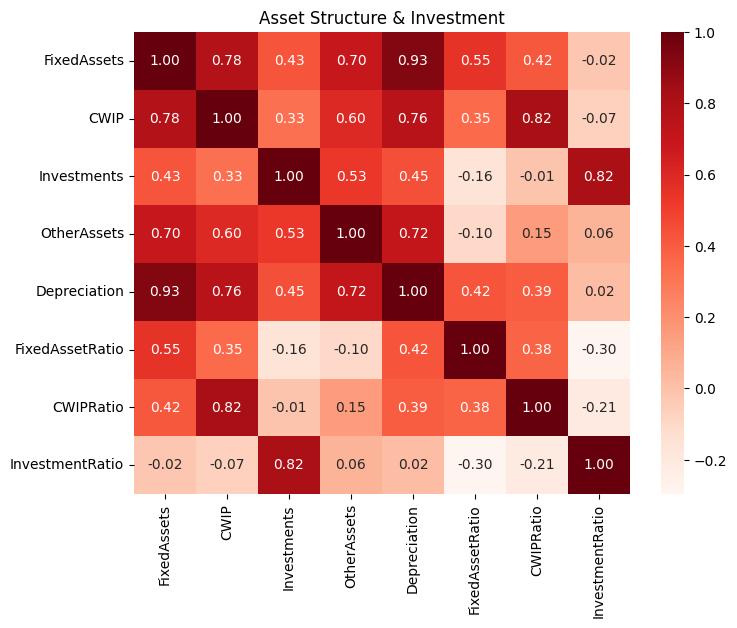

In [29]:
asset_vars = [
    "FixedAssets",
    "CWIP",
    "Investments",
    "OtherAssets",
    "Depreciation",
    "FixedAssetRatio",
    "CWIPRatio",
    "InvestmentRatio"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    X_train[asset_vars].corr(method="spearman"),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Asset Structure & Investment")
plt.show()

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X_train[asset_vars].dropna()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF", ascending=False)

,Variable,VIF
0,FixedAssets,8.612976
4,Depreciation,5.733026
3,OtherAssets,2.917013
1,CWIP,2.785364
2,Investments,1.744885
5,FixedAssetRatio,1.661759
6,CWIPRatio,1.641521
7,InvestmentRatio,1.155758


In [31]:
from scipy.stats import mannwhitneyu

results = []

for col in asset_vars:

    healthy = X_train.loc[y_train == 0, col].dropna()
    distressed = X_train.loc[y_train == 1, col].dropna()

    _, p = mannwhitneyu(
        healthy,
        distressed,
        alternative="two-sided"
    )

    results.append({
        "Variable": col,
        "HealthyMedian": healthy.median(),
        "DistressedMedian": distressed.median(),
        "PValue": p
    })

results = pd.DataFrame(results).sort_values("PValue")
results

,Variable,HealthyMedian,DistressedMedian,PValue
5,FixedAssetRatio,0.329019,0.206597,0.000008
6,CWIPRatio,0.018285,0.013356,0.000097
4,Depreciation,137.000000,78.000000,0.000525
0,FixedAssets,1567.000000,1005.000000,0.001826
1,CWIP,95.000000,65.000000,0.022583
3,OtherAssets,2764.500000,3565.500000,0.072015
7,InvestmentRatio,0.042062,0.042035,0.676626
2,Investments,261.500000,215.000000,0.875973


In [32]:
# ==========================================================
# FILTER 2.4 : ASSET STRUCTURE & INVESTMENT
# ==========================================================

# Selected features
selected_assets = [
    "FixedAssetRatio",
    "CWIPRatio",
    "Depreciation",
    "OtherAssets"
]

# Removed features
removed_assets = [
    "FixedAssets",
    "CWIP",
    "Investments",
    "InvestmentRatio"
]

# Update master lists
selected_features.extend(selected_assets)
removed_features["Asset Structure & Investment"] = removed_assets

# Display
print("Selected Asset Structure Features:")
print(selected_assets)

print("\nRemoved Asset Structure Features:")
print(removed_assets)

Selected Asset Structure Features:
['FixedAssetRatio', 'CWIPRatio', 'Depreciation', 'OtherAssets']

Removed Asset Structure Features:
['FixedAssets', 'CWIP', 'Investments', 'InvestmentRatio']


- FixedAssets and CWIP were removed because their ratio counterparts better represent the underlying financial concepts while reducing dependence on firm size.
- Investments and InvestmentRatio were excluded because they did not significantly differentiate healthy and distressed firms.

5. Operating Efficiency & Business Scale

    Sales,
    AssetTurnover,
    OtherLiabilities,
    EquityCapital

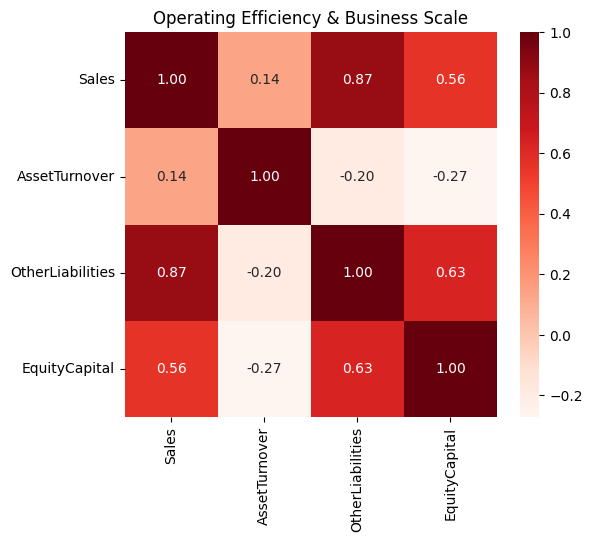

In [33]:
efficiency = [
    "Sales",
    "AssetTurnover",
    "OtherLiabilities",
    "EquityCapital"
]

plt.figure(figsize=(6,5))

sns.heatmap(
    X_train[efficiency].corr(method="spearman"),
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Operating Efficiency & Business Scale")
plt.show()

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X_train[efficiency].dropna()

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF":[
        variance_inflation_factor(X.values,i)
        for i in range(X.shape[1])
    ]
})

vif.sort_values("VIF",ascending=False)

,Variable,VIF
0,Sales,1.919213
2,OtherLiabilities,1.531519
3,EquityCapital,1.215125
1,AssetTurnover,1.117223


In [35]:
from scipy.stats import mannwhitneyu

results=[]

for col in efficiency:

    healthy = X_train.loc[y_train == 0, col].dropna()
    distressed = X_train.loc[y_train == 1, col].dropna()

    _,p = mannwhitneyu(
        healthy,
        distressed,
        alternative="two-sided"
    )

    results.append({
        "Variable":col,
        "HealthyMedian":healthy.median(),
        "DistressedMedian":distressed.median(),
        "PValue":p
    })

pd.DataFrame(results).sort_values("PValue")

,Variable,HealthyMedian,DistressedMedian,PValue
1,AssetTurnover,0.763461,0.384007,1.086961e-15
0,Sales,4424.000000,2822.500000,3.513360e-04
3,EquityCapital,67.000000,113.000000,7.548031e-02
2,OtherLiabilities,1505.500000,2023.500000,1.756507e-01


In [36]:
# ==========================================================
# FILTER 2.5 : OPERATING EFFICIENCY & BUSINESS SCALE
# ==========================================================

# Selected features
selected_efficiency = [
    "Sales",
    "AssetTurnover",
    "OtherLiabilities"
]

# Removed features
removed_efficiency = [
    "EquityCapital"
]

# Update master lists
selected_features.extend(selected_efficiency)
removed_features["Operating Efficiency & Business Scale"] = removed_efficiency

# Display
print("Selected Operating Efficiency Features:")
print(selected_efficiency)

print("\nRemoved Operating Efficiency Features:")
print(removed_efficiency)

Selected Operating Efficiency Features:
['Sales', 'AssetTurnover', 'OtherLiabilities']

Removed Operating Efficiency Features:
['EquityCapital']


- EquityCapital was excluded because it did not significantly differentiate healthy and distressed firms and provides limited information beyond other retained capital structure variables.

In [37]:
selected_controls = [
    "Sector",
    "Year"
]

selected_features.extend(selected_controls)

print(selected_features)
print(len(selected_features))

['NetProfit', 'OperatingProfit', 'ROA', 'CFO', 'FCF', 'CFOtoAssets', 'Interest', 'DebtAssets', 'EquityRatio', 'InterestCoverage', 'FixedAssetRatio', 'CWIPRatio', 'Depreciation', 'OtherAssets', 'Sales', 'AssetTurnover', 'OtherLiabilities', 'Sector', 'Year']
19


In [38]:
X_vif = X_train[selected_features].drop(columns=["Sector", "Year"]).dropna()

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variable,VIF
1,OperatingProfit,28.528118
3,CFO,18.471408
12,Depreciation,12.934618
0,NetProfit,9.889423
13,OtherAssets,8.867076
16,OtherLiabilities,8.108012
6,Interest,6.889758
14,Sales,6.535829
10,FixedAssetRatio,5.551599
8,EquityRatio,5.221310


In [40]:
corr = X_vif.corr().abs()

corr.style.background_gradient(cmap="Reds")

,NetProfit,OperatingProfit,ROA,CFO,FCF,CFOtoAssets,Interest,DebtAssets,EquityRatio,InterestCoverage,FixedAssetRatio,CWIPRatio,Depreciation,OtherAssets,Sales,AssetTurnover,OtherLiabilities
NetProfit,1.000000,0.749149,0.175078,0.653086,0.312054,0.039094,0.223211,0.096151,0.082671,0.087433,0.043111,0.152838,0.330088,0.556021,0.633031,0.012777,0.558580
OperatingProfit,0.749149,1.000000,0.042951,0.883539,0.366693,0.021110,0.710700,0.052620,0.054314,0.041956,0.092850,0.195396,0.828022,0.800915,0.833426,0.059399,0.831031
ROA,0.175078,0.042951,1.000000,0.021320,0.080151,0.207502,0.133614,0.606170,0.617799,0.283258,0.070357,0.027220,0.074076,0.049626,0.010612,0.171919,0.063203
CFO,0.653086,0.883539,0.021320,1.000000,0.601347,0.062114,0.582844,0.030509,0.048690,0.025265,0.135469,0.223187,0.805265,0.629913,0.786210,0.038913,0.761172
FCF,0.312054,0.366693,0.080151,0.601347,1.000000,0.102212,0.080839,0.059808,0.027944,0.067958,0.072390,0.019376,0.275882,0.142838,0.233535,0.019143,0.154639
CFOtoAssets,0.039094,0.021110,0.207502,0.062114,0.102212,1.000000,0.042288,0.071607,0.099244,0.071882,0.043980,0.005738,0.000881,0.044000,0.000710,0.121362,0.027250
Interest,0.223211,0.710700,0.133614,0.582844,0.080839,0.042288,1.000000,0.283480,0.247075,0.063130,0.162403,0.141157,0.793527,0.756017,0.586504,0.179244,0.712457
DebtAssets,0.096151,0.052620,0.606170,0.030509,0.059808,0.071607,0.283480,1.000000,0.810797,0.235920,0.291762,0.131455,0.127077,0.104855,0.043897,0.156361,0.043785
EquityRatio,0.082671,0.054314,0.617799,0.048690,0.027944,0.099244,0.247075,0.810797,1.000000,0.250006,0.060718,0.020925,0.124843,0.162624,0.095840,0.030399,0.174183
InterestCoverage,0.087433,0.041956,0.283258,0.025265,0.067958,0.071882,0.063130,0.235920,0.250006,1.000000,0.106992,0.019731,0.027316,0.013869,0.000276,0.042991,0.027717


In [41]:
X_train = X_train[selected_features].copy()
X_test = X_test[selected_features].copy()

print(X_train.shape)
print(X_test.shape)

(2746, 19)
(1211, 19)


In [42]:
print(y_train.shape)
print(y_test.shape)

(2746,)
(1211,)


### Missing Data Handle

In [43]:
missing_train = pd.DataFrame({
    "MissingCount": X_train.isnull().sum(),
    "MissingPct": (X_train.isnull().mean() * 100).round(2)
})

missing_train = missing_train[missing_train["MissingCount"] > 0]
missing_train.sort_values("MissingPct", ascending=False)

,MissingCount,MissingPct
InterestCoverage,129,4.70
DebtAssets,3,0.11


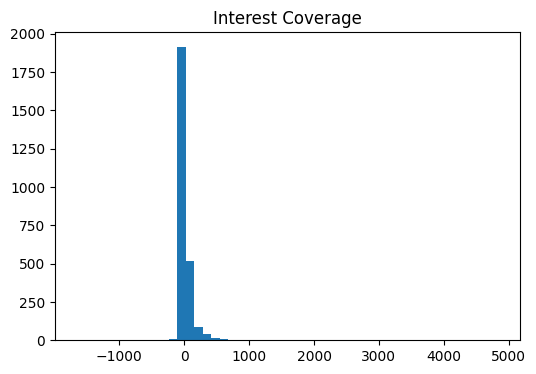

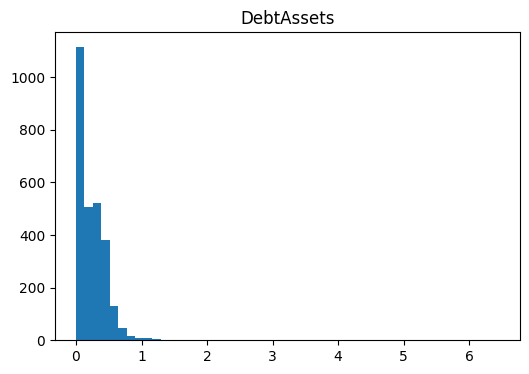

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(X_train["InterestCoverage"].dropna(), bins=50)
plt.title("Interest Coverage")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(X_train["DebtAssets"].dropna(), bins=50)
plt.title("DebtAssets")
plt.show()

In [45]:
print(X_train["InterestCoverage"].skew())
print(X_train["DebtAssets"].skew())

13.310005727737101
7.087790020045487


In [46]:
from sklearn.impute import SimpleImputer

# Numerical columns only
numeric_cols = X_train.select_dtypes(include="number").columns

# Median imputer
median_imputer = SimpleImputer(strategy="median")

# Learn medians from training set
X_train[numeric_cols] = median_imputer.fit_transform(X_train[numeric_cols])

# Apply same medians to test set
X_test[numeric_cols] = median_imputer.transform(X_test[numeric_cols])

In [47]:
print("Missing values in Train")
print(X_train.isna().sum().sum())

print("Missing values in Test")
print(X_test.isna().sum().sum())

Missing values in Train
0
Missing values in Test
0


*Feature Selection by Lasso Regression*

In [48]:
X_train_lasso = X_train[selected_features].copy()

# Drop non-numeric control variables
X_train_lasso = X_train_lasso.drop(columns=["Sector"], errors="ignore")

In [49]:
print(X_train.isna().sum().sum())
print(X_train_lasso.isna().sum().sum())

0
0


In [50]:
from sklearn.linear_model import LogisticRegressionCV

lasso = LogisticRegressionCV(

    penalty="l1",
    solver="liblinear",

    cv=5,

    scoring="average_precision",

    random_state=42,

    max_iter=5000,

    n_jobs=-1

)

lasso.fit(X_train_lasso, y_train)

LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1, penalty='l1',
                     random_state=42, scoring='average_precision',
                     solver='liblinear')

In [51]:
lasso_results = pd.DataFrame({

    "Feature": X_train_lasso.columns,
    "Coefficient": lasso.coef_[0]

})

lasso_results["Absolute"] = lasso_results["Coefficient"].abs()

lasso_results["Selected"] = (
    lasso_results["Coefficient"] != 0
)

lasso_results = lasso_results.sort_values(
    "Absolute",
    ascending=False
)

lasso_results

,Feature,Coefficient,Absolute,Selected
2,ROA,-4.323166,4.323166,True
8,EquityRatio,-2.687919,2.687919,True
5,CFOtoAssets,-0.391003,0.391003,True
10,FixedAssetRatio,-0.366791,0.366791,True
15,AssetTurnover,-0.282336,0.282336,True
9,InterestCoverage,-0.049486,0.049486,True
6,Interest,0.000473,0.000473,True
17,Year,-0.000425,0.000425,True
1,OperatingProfit,-0.000306,0.000306,True
3,CFO,-0.000253,0.000253,True


In [52]:
selected_by_lasso = lasso_results[
    lasso_results["Selected"]
]["Feature"].tolist()

print(f"Number of selected features: {len(selected_by_lasso)}")
print()
print(selected_by_lasso)

Number of selected features: 16

['ROA', 'EquityRatio', 'CFOtoAssets', 'FixedAssetRatio', 'AssetTurnover', 'InterestCoverage', 'Interest', 'Year', 'OperatingProfit', 'CFO', 'NetProfit', 'OtherLiabilities', 'Depreciation', 'OtherAssets', 'Sales', 'FCF']


> LASSO Regression was explored as an alternative model-based feature selection approach.

The `selected_features` showed substantial overlap with the statistically selected features. Lasso Method discarded only two features and that selection doesnot improve model performance exceotionally.

In [53]:
selected_features

['NetProfit',
 'OperatingProfit',
 'ROA',
 'CFO',
 'FCF',
 'CFOtoAssets',
 'Interest',
 'DebtAssets',
 'EquityRatio',
 'InterestCoverage',
 'FixedAssetRatio',
 'CWIPRatio',
 'Depreciation',
 'OtherAssets',
 'Sales',
 'AssetTurnover',
 'OtherLiabilities',
 'Sector',
 'Year']

### Outlier Handling

In [54]:
# Checking Outliers ---> IQR Method

# Numerical columns only (exclude Year)

num_cols = X_train.select_dtypes(include="number").columns.drop("Year")

outlier_summary = []

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

    outlier_summary.append({
        "Variable": col,
        "Outliers": outliers,
        "Percentage": round(outliers / len(X_train) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Percentage",
    ascending=False
)

outlier_df

,Variable,Outliers,Percentage
4,FCF,499,18.17
3,CFO,429,15.62
9,InterestCoverage,425,15.48
16,OtherLiabilities,420,15.29
0,NetProfit,415,15.11
12,Depreciation,397,14.46
14,Sales,388,14.13
1,OperatingProfit,379,13.80
6,Interest,364,13.26
13,OtherAssets,354,12.89


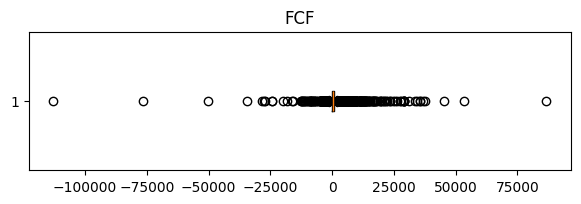

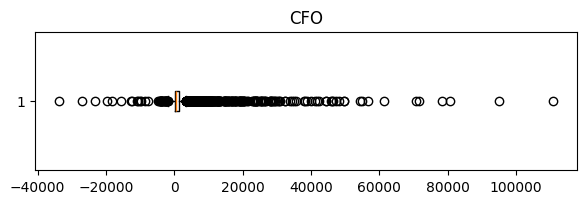

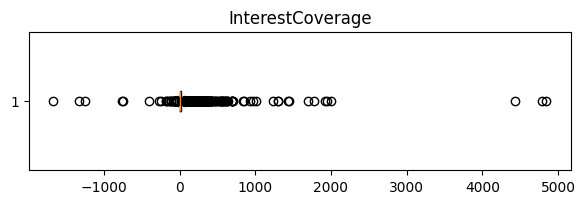

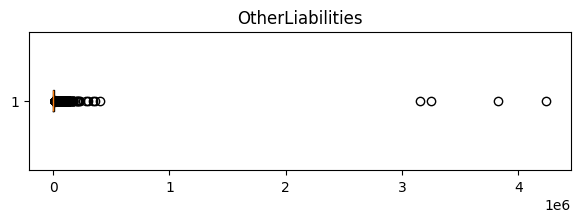

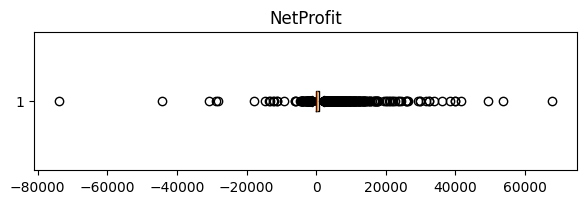

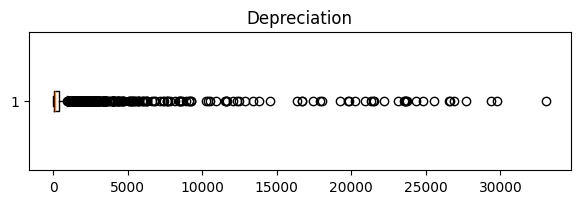

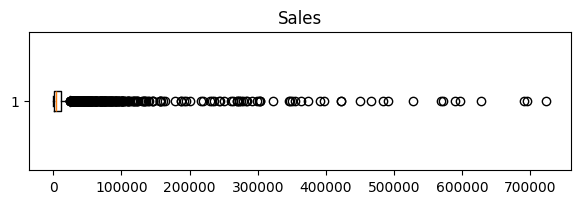

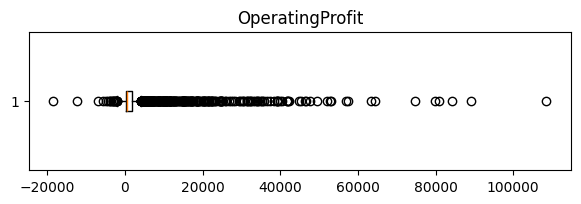

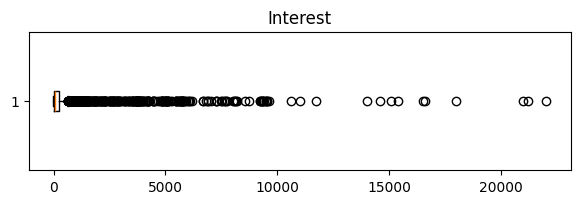

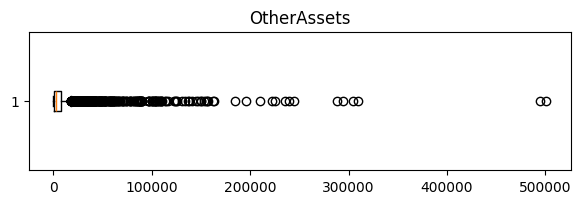

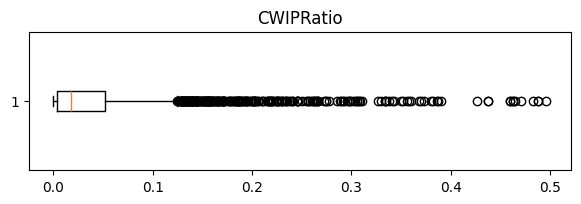

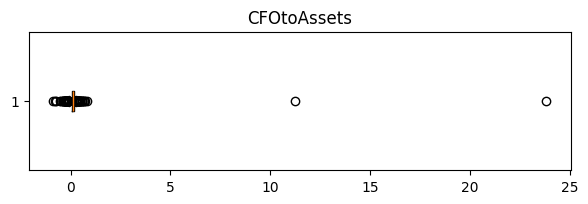

In [55]:
import matplotlib.pyplot as plt

high_outlier_vars = outlier_df.loc[
    outlier_df["Percentage"] > 5,
    "Variable"
]

for col in high_outlier_vars:

    plt.figure(figsize=(7,1.8))

    plt.boxplot(
        X_train[col].dropna(),
        vert=False
    )

    plt.title(col)

    plt.show()

In [56]:
outlier_side = []

for col in num_cols:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    lower_out = (X_train[col] < lower).sum()
    upper_out = (X_train[col] > upper).sum()

    outlier_side.append({
        "Variable": col,
        "Lower": lower_out,
        "Upper": upper_out
    })

pd.DataFrame(outlier_side).sort_values("Upper", ascending=False)

,Variable,Lower,Upper
16,OtherLiabilities,0,420
12,Depreciation,0,397
9,InterestCoverage,33,392
3,CFO,39,390
14,Sales,0,388
6,Interest,0,364
1,OperatingProfit,20,359
4,FCF,143,356
13,OtherAssets,0,354
0,NetProfit,65,350


* Winsorization

In [57]:
# Numerical columns only (exclude Year)
num_cols = X_train.select_dtypes(include="number").columns.drop("Year")

winsor_limits = pd.DataFrame(index=num_cols,
                             columns=["Lower", "Upper"])

for col in num_cols:
    winsor_limits.loc[col, "Lower"] = X_train[col].quantile(0.01)
    winsor_limits.loc[col, "Upper"] = X_train[col].quantile(0.99)

winsor_limits

,Lower,Upper
NetProfit,-3395.6,20238.75
OperatingProfit,-1442.25,39125.55
ROA,-0.215641,0.3
CFO,-2858.7,34697.95
FCF,-8645.4,19599.7
CFOtoAssets,-0.203551,0.341732
Interest,0.0,8385.35
DebtAssets,0.0,0.874122
EquityRatio,-0.180577,0.914342
InterestCoverage,-45.929706,600.685


In [58]:
X_train_w = X_train.copy()
X_test_w = X_test.copy()

for col in num_cols:

    lower = winsor_limits.loc[col, "Lower"]
    upper = winsor_limits.loc[col, "Upper"]

    X_train_w[col] = X_train_w[col].clip(lower=lower,
                                         upper=upper)

    X_test_w[col] = X_test_w[col].clip(lower=lower,
                                       upper=upper)

In [59]:
change_summary = []

for col in num_cols:

    changed = (X_train[col] != X_train_w[col]).sum()

    pct = changed / len(X_train) * 100

    change_summary.append({
        "Variable": col,
        "ChangedRows": changed,
        "ChangedPct": round(pct,2)
    })

change_summary = (
    pd.DataFrame(change_summary)
      .sort_values("ChangedPct",
                   ascending=False)
)

change_summary

,Variable,ChangedRows,ChangedPct
0,NetProfit,56,2.04
1,OperatingProfit,56,2.04
3,CFO,56,2.04
4,FCF,56,2.04
5,CFOtoAssets,56,2.04
8,EquityRatio,56,2.04
14,Sales,56,2.04
10,FixedAssetRatio,56,2.04
9,InterestCoverage,56,2.04
15,AssetTurnover,56,2.04


In [60]:
comparison = pd.DataFrame({
    "Min Before": X_train[num_cols].min(),
    "Min After": X_train_w[num_cols].min(),

    "Max Before": X_train[num_cols].max(),
    "Max After": X_train_w[num_cols].max(),

    "Mean Before": X_train[num_cols].mean(),
    "Mean After": X_train_w[num_cols].mean()
})

comparison

,Min Before,Min After,Max Before,Max After,Mean Before,Mean After
NetProfit,-73878.000000,-3395.600000,6.784500e+04,20238.750000,1233.620175,1220.691260
OperatingProfit,-18479.000000,-1442.250000,1.085810e+05,39125.550000,2732.265113,2585.480117
ROA,-4.396040,-0.215641,9.818623e-01,0.300000,0.066644,0.069032
CFO,-33670.000000,-2858.700000,1.106540e+05,34697.950000,2279.513474,2155.500728
FCF,-112909.000000,-8645.400000,8.676500e+04,19599.700000,894.270575,917.842098
CFOtoAssets,-0.872558,-0.203551,2.384000e+01,0.341732,0.107849,0.095531
Interest,-14.000000,0.000000,2.202700e+04,8385.350000,551.785870,510.827677
DebtAssets,0.000000,0.000000,6.448845e+00,0.874122,0.230691,0.225729
EquityRatio,-5.825050,-0.180577,9.979265e-01,0.914342,0.472586,0.479722
InterestCoverage,-1668.000000,-45.929706,4.846000e+03,600.685000,43.441750,37.140784


In [61]:
# Replace original datasets with winsorized datasets
X_train = X_train_w.copy()
X_test = X_test_w.copy()

In [62]:
print("Shape:", X_train.shape)

print("\nMaximum Sales:", X_train["Sales"].max())
print("Minimum NetProfit:", X_train["NetProfit"].min())
print("Minimum InterestCoverage:", X_train["InterestCoverage"].min())

Shape: (2746, 19)

Maximum Sales: 295221.8000000012
Minimum NetProfit: -3395.6
Minimum InterestCoverage: -45.92970588235294


In [63]:
for col in num_cols:

    upper = winsor_limits.loc[col, "Upper"]
    lower = winsor_limits.loc[col, "Lower"]

    print(
        col,
        (X_train[col] > upper).sum(),
        (X_train[col] < lower).sum()
    )

NetProfit 0 0
OperatingProfit 0 0
ROA 0 0
CFO 0 0
FCF 0 0
CFOtoAssets 0 0
Interest 0 0
DebtAssets 0 0
EquityRatio 0 0
InterestCoverage 0 0
FixedAssetRatio 0 0
CWIPRatio 0 0
Depreciation 0 0
OtherAssets 0 0
Sales 0 0
AssetTurnover 0 0
OtherLiabilities 0 0


### Standardization on `numeric_cols`

In [64]:
numeric_cols = [
    "NetProfit",
    "OperatingProfit",
    "ROA",
    "CFO",
    "FCF",
    "CFOtoAssets",
    "Interest",
    "DebtAssets",
    "EquityRatio",
    "InterestCoverage",
    "FixedAssetRatio",
    "CWIPRatio",
    "Depreciation",
    "OtherAssets",
    "Sales",
    "AssetTurnover",
    "OtherLiabilities"
]

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [66]:
X_train[numeric_cols].agg(["mean", "std"]).T.round(3)

,mean,std
NetProfit,-0.0,1.0
OperatingProfit,0.0,1.0
ROA,-0.0,1.0
CFO,-0.0,1.0
FCF,-0.0,1.0
CFOtoAssets,0.0,1.0
Interest,0.0,1.0
DebtAssets,-0.0,1.0
EquityRatio,0.0,1.0
InterestCoverage,0.0,1.0


In [67]:
X_train.head()

X_train.columns.tolist()

['NetProfit',
 'OperatingProfit',
 'ROA',
 'CFO',
 'FCF',
 'CFOtoAssets',
 'Interest',
 'DebtAssets',
 'EquityRatio',
 'InterestCoverage',
 'FixedAssetRatio',
 'CWIPRatio',
 'Depreciation',
 'OtherAssets',
 'Sales',
 'AssetTurnover',
 'OtherLiabilities',
 'Sector',
 'Year']

### Class Imbalance Handling

#### *SMOTNEC Technique*

In [68]:
from imblearn.over_sampling import SMOTENC


categorical_features = [
    X_train.columns.get_loc("Sector"),
    X_train.columns.get_loc("Year")
]

smote_nc = SMOTENC(
    categorical_features=categorical_features,
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote_nc.fit_resample(
    X_train,
    y_train
)

print("New Training Shape :", X_train.shape)
print("\nClass Distribution:")
print(y_train.value_counts())

New Training Shape : (5176, 19)

Class Distribution:
FutureDistress
0    2588
1    2588
Name: count, dtype: int64


*Continuous financial variables were standardized prior to SMOTENC to ensure that the k-nearest-neighbour distance calculations were not dominated by variables with larger numerical scales. The categorical Sector variable was excluded from standardization and handled natively by SMOTENC.*

### OHE in Sector

In [69]:
print(X_train["Sector"].nunique())
print(sorted(X_train["Sector"].unique()))

11
['Basic Materials', 'Communication Services', 'Consumer Cyclical', 'Consumer Defensive', 'Energy', 'Financial Services', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']


In [70]:
# One-Hot Encode Sector

X_train = pd.get_dummies(
    X_train,
    columns=["Sector"],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["Sector"],
    drop_first=True,
    dtype=int
)

In [71]:
# Align Train and Test
# Sometimes a sector exists in Train but not Test (or vice versa).

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [72]:
print(X_train.shape)
print(X_test.shape)

print()

print(X_train.columns.equals(X_test.columns))

(5176, 28)
(1211, 28)

True


In [73]:
X_train.columns.tolist()
# (11-1) = 10 dummies

['NetProfit',
 'OperatingProfit',
 'ROA',
 'CFO',
 'FCF',
 'CFOtoAssets',
 'Interest',
 'DebtAssets',
 'EquityRatio',
 'InterestCoverage',
 'FixedAssetRatio',
 'CWIPRatio',
 'Depreciation',
 'OtherAssets',
 'Sales',
 'AssetTurnover',
 'OtherLiabilities',
 'Year',
 'Sector_Communication Services',
 'Sector_Consumer Cyclical',
 'Sector_Consumer Defensive',
 'Sector_Energy',
 'Sector_Financial Services',
 'Sector_Healthcare',
 'Sector_Industrials',
 'Sector_Real Estate',
 'Sector_Technology',
 'Sector_Utilities']

In [74]:
X_train["Year"].sample(5)

,Year
365,2016.0
1501,2019.0
1838,2015.0
3369,2021.0
4782,2016.0


In [75]:
X_train["Year"] = X_train["Year"].astype(int)
X_test["Year"] = X_test["Year"].astype(int)

In [76]:
X_train.dtypes

,0
NetProfit,float64
OperatingProfit,float64
ROA,float64
CFO,float64
FCF,float64
CFOtoAssets,float64
Interest,float64
DebtAssets,float64
EquityRatio,float64
InterestCoverage,float64


In [77]:
X_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
NetProfit,5176.0,-0.250232,0.834350,-1.474743,-0.466891,-0.366647,-0.224676,6.075602
OperatingProfit,5176.0,-0.136570,0.815538,-0.658374,-0.423613,-0.374403,-0.209267,5.972855
ROA,5176.0,-0.767018,1.327015,-3.579514,-1.402023,-0.659598,-0.032310,2.904224
CFO,5176.0,-0.157425,0.806889,-0.926961,-0.409758,-0.348752,-0.218995,6.016029
FCF,5176.0,-0.192957,0.896628,-2.899332,-0.367945,-0.258863,-0.133880,5.663865
CFOtoAssets,5176.0,-0.575017,1.261343,-3.332607,-1.213698,-0.439382,0.203705,2.743375
Interest,5176.0,0.149785,1.200801,-0.373108,-0.358467,-0.292726,-0.070911,5.751543
DebtAssets,5176.0,0.450994,1.318779,-1.130218,-0.775173,0.253978,1.348177,3.246488
EquityRatio,5176.0,-0.439475,1.272780,-2.908032,-1.245363,-0.478843,0.585989,1.914118
InterestCoverage,5176.0,-0.234238,0.779808,-0.913277,-0.408641,-0.386292,-0.321579,6.195607


In [78]:
print(y_train.value_counts())

print()

print(y_train.value_counts(normalize=True))

FutureDistress
0    2588
1    2588
Name: count, dtype: int64

FutureDistress
0    0.5
1    0.5
Name: proportion, dtype: float64


In [79]:
print(X_train.shape)
print(X_test.shape)

(5176, 28)
(1211, 28)


## Model Training & Evaluation

Importing Libraries

In [80]:
import numpy as np
import pandas as pd

!pip install catboost

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [81]:
# Checking Final dataset

print("="*50)
print("FINAL DATASET")
print("="*50)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

FINAL DATASET

Training Shape : (5176, 28)
Testing Shape  : (1211, 28)

Training Class Distribution
FutureDistress
0    2588
1    2588
Name: count, dtype: int64

Testing Class Distribution
FutureDistress
0    1156
1      55
Name: count, dtype: int64


Universal Evaluation Function

In [82]:
# Stores evaluation metrics
results = []

# Stores predicted probabilities (for ROC, PR curves, threshold tuning)
model_probs = {}

# Stores trained models (for feature importance, SHAP, etc.)
trained_models = {}

def evaluate_model(model, model_name):

    print("="*70)
    print(model_name)
    print("="*70)

    # Train
    model.fit(X_train, y_train)

    # Save trained model
    trained_models[model_name] = model

    # Predictions
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    # Store probabilities for ROC/PR curves
    model_probs[model_name] = y_prob

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    # Save
    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc,

        "PR_AUC": pr_auc

    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))


    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Healthy (0)", "Distressed (1)"],
        yticklabels=["Healthy (0)", "Distressed (1)"]
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"Confusion Matrix - {model_name}")

    plt.show()

    return model

`Logistic Regression`

Logistic Regression
Accuracy : 0.9315
Precision: 0.3750
Recall   : 0.7636
F1 Score : 0.5030
ROC-AUC  : 0.9382
PR-AUC   : 0.6277

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1156
           1       0.38      0.76      0.50        55

    accuracy                           0.93      1211
   macro avg       0.68      0.85      0.73      1211
weighted avg       0.96      0.93      0.94      1211



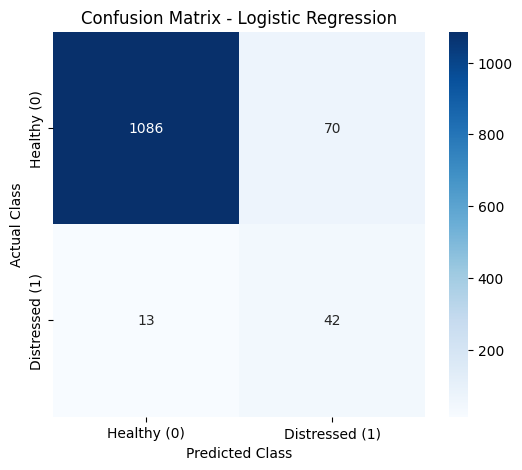

In [83]:
lr = LogisticRegression(
    random_state=42,
    max_iter=3000
)

lr = evaluate_model(
    lr,
    "Logistic Regression"
)

`Decision Tree`

Decision Tree
Accuracy : 0.9438
Precision: 0.4058
Recall   : 0.5091
F1 Score : 0.4516
ROC-AUC  : 0.7368
PR-AUC   : 0.2289

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1156
           1       0.41      0.51      0.45        55

    accuracy                           0.94      1211
   macro avg       0.69      0.74      0.71      1211
weighted avg       0.95      0.94      0.95      1211



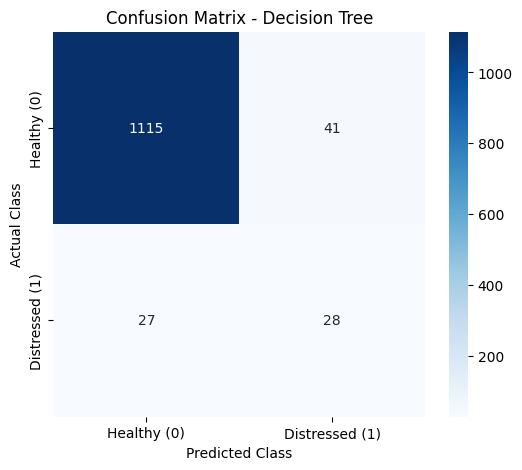

In [84]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt = evaluate_model(
    dt,
    "Decision Tree"
)

`Random Forest`

Random Forest
Accuracy : 0.9703
Precision: 0.6301
Recall   : 0.8364
F1 Score : 0.7188
ROC-AUC  : 0.9856
PR-AUC   : 0.7102

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1156
           1       0.63      0.84      0.72        55

    accuracy                           0.97      1211
   macro avg       0.81      0.91      0.85      1211
weighted avg       0.98      0.97      0.97      1211



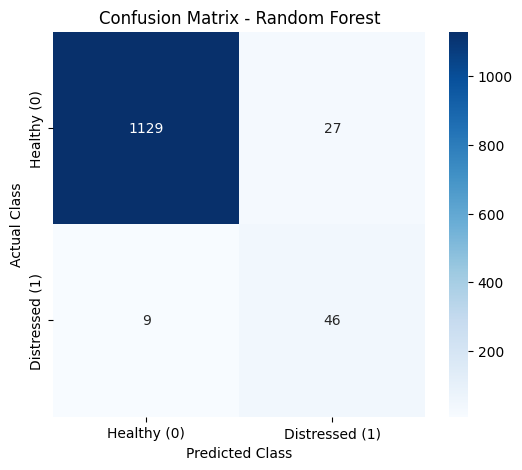

In [85]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf = evaluate_model(
    rf,
    "Random Forest"
)

`XGBoost`

XGBoost
Accuracy : 0.9686
Precision: 0.6104
Recall   : 0.8545
F1 Score : 0.7121
ROC-AUC  : 0.9865
PR-AUC   : 0.7106

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1156
           1       0.61      0.85      0.71        55

    accuracy                           0.97      1211
   macro avg       0.80      0.91      0.85      1211
weighted avg       0.98      0.97      0.97      1211



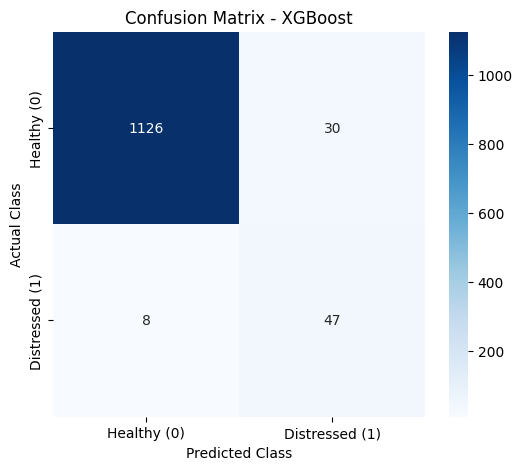

In [86]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1
)

xgb = evaluate_model(
    xgb,
    "XGBoost"
)

`LightGBM`

LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2588, number of negative: 2588
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4373
[LightGBM] [Info] Number of data points in the train set: 5176, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy : 0.9670
Precision: 0.5949
Recall   : 0.8545
F1 Score : 0.7015
ROC-AUC  : 0.9870
PR-AUC   : 0.7334

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1156
           1       0.59      0.85      0.70        55

    accuracy                           0.97      1211
   macro avg       0.79      0.91      0.84      1211
weighted avg       0.97      0.97      0.97      1211



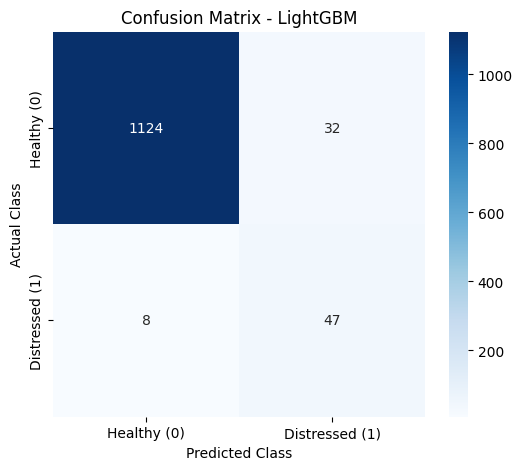

In [87]:
lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

lgbm = evaluate_model(
    lgbm,
    "LightGBM"
)

`CatBoost`

CatBoost
Accuracy : 0.9637
Precision: 0.5632
Recall   : 0.8909
F1 Score : 0.6901
ROC-AUC  : 0.9868
PR-AUC   : 0.7340

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1156
           1       0.56      0.89      0.69        55

    accuracy                           0.96      1211
   macro avg       0.78      0.93      0.84      1211
weighted avg       0.98      0.96      0.97      1211



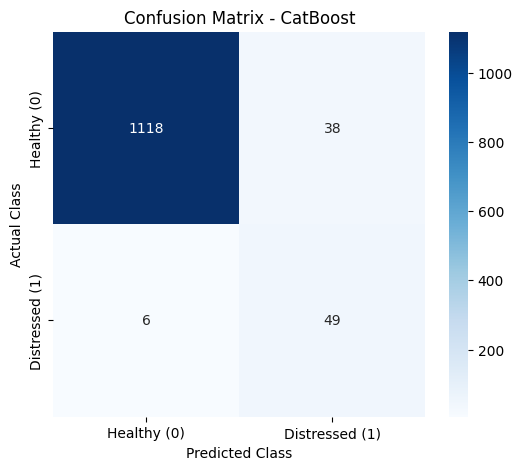

In [88]:
cat = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat = evaluate_model(
    cat,
    "CatBoost"
)

### Comparision

In [89]:
comparison = (
    pd.DataFrame(results)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.963666,0.563218,0.890909,0.690141,0.986757,0.734025
1,LightGBM,0.966969,0.594937,0.854545,0.701493,0.986993,0.733405
2,XGBoost,0.968621,0.610390,0.854545,0.712121,0.986482,0.710622
3,Random Forest,0.970273,0.630137,0.836364,0.718750,0.985624,0.710158
4,Logistic Regression,0.931462,0.375000,0.763636,0.502994,0.938157,0.627659
5,Decision Tree,0.943848,0.405797,0.509091,0.451613,0.736812,0.228883


*ROC Curve Comparision*

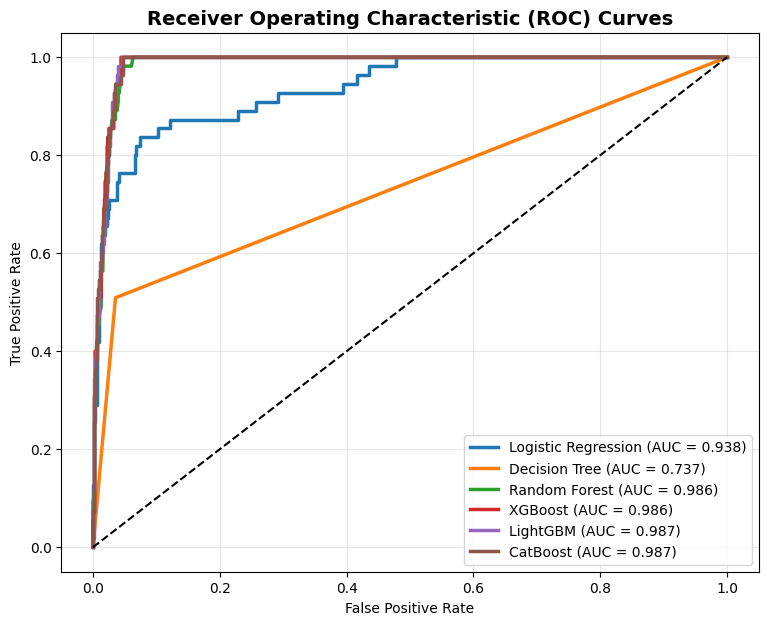

In [90]:
plt.figure(figsize=(9,7))

for model_name, y_prob in model_probs.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Receiver Operating Characteristic (ROC) Curves",
    fontsize=14,
    weight='bold'
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

*Precision–Recall Curve Comparision*

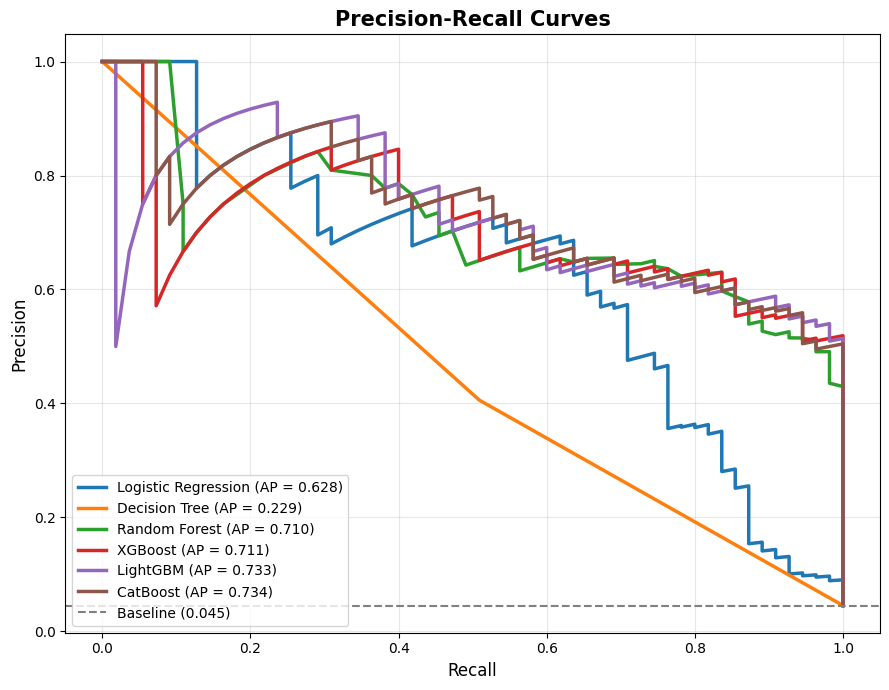

In [91]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(9,7))

for model_name, y_prob in model_probs.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2.5,
        label=f"{model_name} (AP = {ap:.3f})"
    )

# Baseline
baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)

plt.title(
    "Precision-Recall Curves",
    fontsize=15,
    weight="bold"
)

plt.grid(alpha=0.3)

plt.legend(loc="lower left")

plt.tight_layout()

plt.show()

Since financial distress is a rare event, the Precision–Recall curve provides a more meaningful evaluation than accuracy alone.

> Models with higher Average Precision (AP) are better at identifying distressed companies while maintaining higher precision across different recall levels.


> A model with a higher PR-AUC means:

* It catches a large proportion of truly distressed firms (high recall).

* A larger fraction of the flagged firms are genuinely at risk (high precision).

#### *For an Early Warning System, missing a genuinely distressed company (false negative) can have more severe consequences than issuing a false alarm (false positive).*
> Therefore, models with higher Precision–Recall performance are generally more
desirable, as they are capable of detecting a larger proportion of distressed
firms while keeping the number of unnecessary investigations relatively low.


---



## Hyperparameter Tuning

In [92]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.7 MB/s eta 0:00:00


In [93]:
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [94]:
# Optimization Metric --> average_precision
# Why? --> my dataset (test) is highly imbalanced inspite of being tackled by smotnec

* Cross Validation

In [95]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

* Model Dictionary ( Selected based on base-line results )

In [96]:
models = {

    "Random Forest": RandomForestClassifier,

    "XGBoost": XGBClassifier,

    "LightGBM": LGBMClassifier,

    "CatBoost": CatBoostClassifier

}

* Search Spaces

In [97]:
search_spaces = {

    "Random Forest": {

        "n_estimators": (100,300),

        "max_depth": (5,15),

        "min_samples_split": (2,10)

    },

    "XGBoost": {

        "n_estimators": (100,300),

        "max_depth": (3,8),

        "learning_rate": (0.01,0.20)

    },

    "LightGBM": {

        "n_estimators": (100,300),

        "num_leaves": (20,80),

        "learning_rate": (0.01,0.20)

    },

    "CatBoost": {

        "iterations": (100,300),

        "depth": (4,8),

        "learning_rate": (0.01,0.20)

    }

}

* Generic Objective

In [98]:
def objective(trial, model_name):

    if model_name=="Random Forest":

        model = RandomForestClassifier(

            n_estimators=trial.suggest_int("n_estimators",100,300),

            max_depth=trial.suggest_int("max_depth",5,15),

            min_samples_split=trial.suggest_int("min_samples_split",2,10),

            random_state=42,

            n_jobs=-1

        )

    elif model_name=="XGBoost":

        model = XGBClassifier(

            n_estimators=trial.suggest_int("n_estimators",100,300),

            max_depth=trial.suggest_int("max_depth",3,8),

            learning_rate=trial.suggest_float(
                "learning_rate",
                0.01,
                0.20
            ),

            eval_metric="logloss",

            random_state=42

        )

    elif model_name=="LightGBM":

        model = LGBMClassifier(

            n_estimators=trial.suggest_int("n_estimators",100,300),

            num_leaves=trial.suggest_int("num_leaves",20,80),

            learning_rate=trial.suggest_float(
                "learning_rate",
                0.01,
                0.20
            ),

            random_state=42,

            verbose=-1

        )

    else:

        model = CatBoostClassifier(

            iterations=trial.suggest_int("iterations",100,300),

            depth=trial.suggest_int("depth",4,8),

            learning_rate=trial.suggest_float(
                "learning_rate",
                0.01,
                0.20
            ),

            verbose=0,

            random_state=42

        )

    score = cross_val_score(

        model,

        X_train,

        y_train,

        scoring="average_precision",

        cv=cv,

        n_jobs=1

    ).mean()

    return score

* Tuning

In [99]:
from optuna.samplers import TPESampler


best_params = {}

for name in models.keys():

    print("="*60)

    print(name)

    print("="*60)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42)
    )

    study.optimize(

        lambda trial: objective(trial,name),

        n_trials=10,

        show_progress_bar=True

    )

    best_params[name]=study.best_params

    print("Best AP:",study.best_value)

    print(study.best_params)

[I 2026-07-18 16:39:54,997] A new study created in memory with name: no-name-3abcecff-a4e7-493f-9fdc-b11347c02711


Random Forest


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-18 16:40:14,740] Trial 0 finished with value: 0.9956898491861169 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}. Best is trial 0 with value: 0.9956898491861169.
[I 2026-07-18 16:40:37,583] Trial 1 finished with value: 0.9895438589777525 and parameters: {'n_estimators': 220, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 0 with value: 0.9956898491861169.
[I 2026-07-18 16:40:50,022] Trial 2 finished with value: 0.995491546146815 and parameters: {'n_estimators': 111, 'max_depth': 14, 'min_samples_split': 7}. Best is trial 0 with value: 0.9956898491861169.
[I 2026-07-18 16:40:59,925] Trial 3 finished with value: 0.986454631553675 and parameters: {'n_estimators': 242, 'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.9956898491861169.
[I 2026-07-18 16:41:14,052] Trial 4 finished with value: 0.9929803773799186 and parameters: {'n_estimators': 267, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 0 with value: 0.99

[I 2026-07-18 16:42:04,484] A new study created in memory with name: no-name-9fe055da-8b8c-4d27-b639-97f7eee77b64


[I 2026-07-18 16:42:04,479] Trial 9 finished with value: 0.9962946319769242 and parameters: {'n_estimators': 203, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 8 with value: 0.9965957744234715.
Best AP: 0.9965957744234715
{'n_estimators': 191, 'max_depth': 13, 'min_samples_split': 3}
XGBoost


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-18 16:42:09,536] Trial 0 finished with value: 0.9938525318688616 and parameters: {'n_estimators': 175, 'max_depth': 8, 'learning_rate': 0.14907884894416698}. Best is trial 0 with value: 0.9938525318688616.
[I 2026-07-18 16:42:11,171] Trial 1 finished with value: 0.9899748658956948 and parameters: {'n_estimators': 220, 'max_depth': 3, 'learning_rate': 0.039638958863878505}. Best is trial 0 with value: 0.9938525318688616.
[I 2026-07-18 16:42:13,594] Trial 2 finished with value: 0.9941336736126422 and parameters: {'n_estimators': 111, 'max_depth': 8, 'learning_rate': 0.12421185223120967}. Best is trial 2 with value: 0.9941336736126422.
[I 2026-07-18 16:42:15,259] Trial 3 finished with value: 0.9938739397969403 and parameters: {'n_estimators': 242, 'max_depth': 3, 'learning_rate': 0.19428287191077892}. Best is trial 2 with value: 0.9941336736126422.
[I 2026-07-18 16:42:17,849] Trial 4 finished with value: 0.993165252335044 and parameters: {'n_estimators': 267, 'max_depth': 4, 'l

[I 2026-07-18 16:42:35,923] A new study created in memory with name: no-name-a2d83e0f-829d-465c-a174-876f95ad91ea


[I 2026-07-18 16:42:35,912] Trial 9 finished with value: 0.9905987240907634 and parameters: {'n_estimators': 203, 'max_depth': 6, 'learning_rate': 0.01882557841679957}. Best is trial 2 with value: 0.9941336736126422.
Best AP: 0.9941336736126422
{'n_estimators': 111, 'max_depth': 8, 'learning_rate': 0.12421185223120967}
LightGBM


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-18 16:42:39,521] Trial 0 finished with value: 0.9950055505258277 and parameters: {'n_estimators': 175, 'num_leaves': 77, 'learning_rate': 0.14907884894416698}. Best is trial 0 with value: 0.9950055505258277.
[I 2026-07-18 16:42:42,638] Trial 1 finished with value: 0.9940164853885202 and parameters: {'n_estimators': 220, 'num_leaves': 29, 'learning_rate': 0.039638958863878505}. Best is trial 0 with value: 0.9950055505258277.
[I 2026-07-18 16:42:46,179] Trial 2 finished with value: 0.995167229125788 and parameters: {'n_estimators': 111, 'num_leaves': 72, 'learning_rate': 0.12421185223120967}. Best is trial 2 with value: 0.995167229125788.
[I 2026-07-18 16:42:49,212] Trial 3 finished with value: 0.9959451266367202 and parameters: {'n_estimators': 242, 'num_leaves': 21, 'learning_rate': 0.19428287191077892}. Best is trial 3 with value: 0.9959451266367202.
[I 2026-07-18 16:42:53,342] Trial 4 finished with value: 0.9951016661405522 and parameters: {'n_estimators': 267, 'num_leaves

[I 2026-07-18 16:43:12,221] A new study created in memory with name: no-name-5bd890dc-451d-46ed-bbed-b61505e87faa


[I 2026-07-18 16:43:12,211] Trial 9 finished with value: 0.9895755348625483 and parameters: {'n_estimators': 203, 'num_leaves': 56, 'learning_rate': 0.01882557841679957}. Best is trial 3 with value: 0.9959451266367202.
Best AP: 0.9959451266367202
{'n_estimators': 242, 'num_leaves': 21, 'learning_rate': 0.19428287191077892}
CatBoost


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-18 16:43:29,173] Trial 0 finished with value: 0.9958401521554109 and parameters: {'iterations': 175, 'depth': 8, 'learning_rate': 0.14907884894416698}. Best is trial 0 with value: 0.9958401521554109.
[I 2026-07-18 16:43:32,774] Trial 1 finished with value: 0.9920017616167897 and parameters: {'iterations': 220, 'depth': 4, 'learning_rate': 0.039638958863878505}. Best is trial 0 with value: 0.9958401521554109.
[I 2026-07-18 16:43:45,080] Trial 2 finished with value: 0.9950450220755928 and parameters: {'iterations': 111, 'depth': 8, 'learning_rate': 0.12421185223120967}. Best is trial 0 with value: 0.9958401521554109.
[I 2026-07-18 16:43:48,976] Trial 3 finished with value: 0.9938820856530795 and parameters: {'iterations': 242, 'depth': 4, 'learning_rate': 0.19428287191077892}. Best is trial 0 with value: 0.9958401521554109.
[I 2026-07-18 16:43:57,133] Trial 4 finished with value: 0.9941709781888738 and parameters: {'iterations': 267, 'depth': 5, 'learning_rate': 0.044546743769

* Best Parameters of each model

In [100]:
best_params

{'Random Forest': {'n_estimators': 191,
  'max_depth': 13,
  'min_samples_split': 3},
 'XGBoost': {'n_estimators': 111,
  'max_depth': 8,
  'learning_rate': 0.12421185223120967},
 'LightGBM': {'n_estimators': 242,
  'num_leaves': 21,
  'learning_rate': 0.19428287191077892},
 'CatBoost': {'iterations': 175,
  'depth': 8,
  'learning_rate': 0.14907884894416698}}

In [101]:
# ============================================================
# Optimized Models using Optuna Best Hyperparameters
# ============================================================

optimized_models = {

    "Optimized Random Forest": RandomForestClassifier(
        **best_params["Random Forest"],
        random_state=42,
        n_jobs=-1
    ),

    "Optimized XGBoost": XGBClassifier(
        **best_params["XGBoost"],
        random_state=42,
        eval_metric="logloss"
    ),

    "Optimized LightGBM": LGBMClassifier(
        **best_params["LightGBM"],
        random_state=42,
        verbose=-1
    ),

    "Optimized CatBoost": CatBoostClassifier(
        **best_params["CatBoost"],
        random_state=42,
        verbose=0
    )

}



for name, model in optimized_models.items():

    model.fit(X_train, y_train)

print("All optimized models trained successfully.")

All optimized models trained successfully.


Optimized Random Forest
Accuracy : 0.9703
Precision: 0.6267
Recall   : 0.8545
F1 Score : 0.7231
ROC-AUC  : 0.9875
PR-AUC   : 0.7522

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1156
           1       0.63      0.85      0.72        55

    accuracy                           0.97      1211
   macro avg       0.81      0.92      0.85      1211
weighted avg       0.98      0.97      0.97      1211



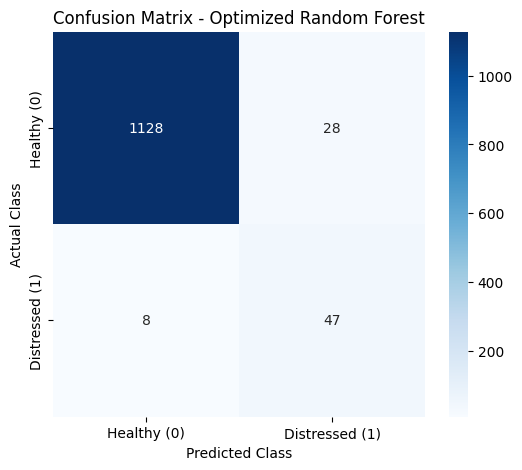

Optimized XGBoost
Accuracy : 0.9653
Precision: 0.5867
Recall   : 0.8000
F1 Score : 0.6769
ROC-AUC  : 0.9866
PR-AUC   : 0.7267

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1156
           1       0.59      0.80      0.68        55

    accuracy                           0.97      1211
   macro avg       0.79      0.89      0.83      1211
weighted avg       0.97      0.97      0.97      1211



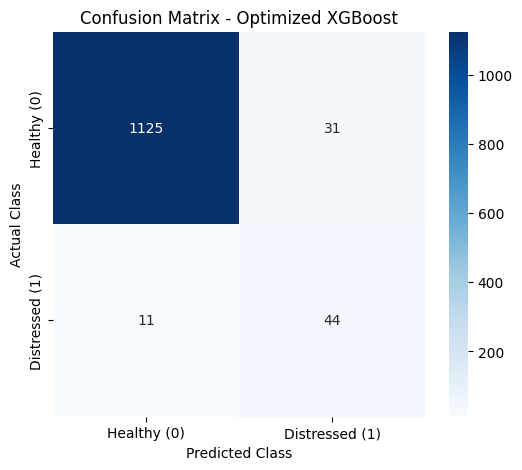

Optimized LightGBM
Accuracy : 0.9727
Precision: 0.6447
Recall   : 0.8909
F1 Score : 0.7481
ROC-AUC  : 0.9864
PR-AUC   : 0.7052

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1156
           1       0.64      0.89      0.75        55

    accuracy                           0.97      1211
   macro avg       0.82      0.93      0.87      1211
weighted avg       0.98      0.97      0.97      1211



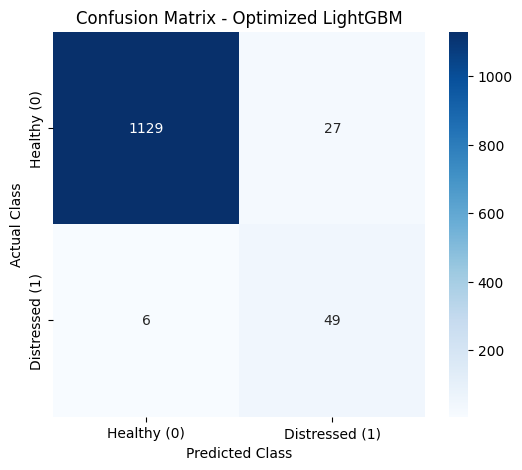

Optimized CatBoost
Accuracy : 0.9604
Precision: 0.5385
Recall   : 0.8909
F1 Score : 0.6712
ROC-AUC  : 0.9857
PR-AUC   : 0.7054

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1156
           1       0.54      0.89      0.67        55

    accuracy                           0.96      1211
   macro avg       0.77      0.93      0.83      1211
weighted avg       0.97      0.96      0.96      1211



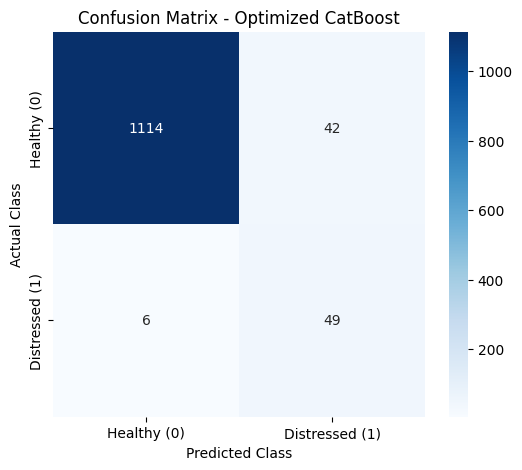

In [102]:
baseline_results = pd.DataFrame(results).copy()

results = []
model_probs = {}
trained_models = {}

for name, model in optimized_models.items():
    evaluate_model(model, name)

optimized_results = pd.DataFrame(results).copy()

In [103]:
comparison = (
    baseline_results[
        ["Model",
         "Accuracy",
         "Precision",
         "Recall",
         "F1",
         "ROC_AUC",
         "PR_AUC"]
    ]
    .merge(
        optimized_results[
            ["Model",
             "Accuracy",
             "Precision",
             "Recall",
             "F1",
             "ROC_AUC",
             "PR_AUC"]
        ],
        left_on="Model",
        right_on=optimized_results["Model"].str.replace("Optimized ", ""),
        suffixes=("_Baseline", "_Optimized")
    )
)


for metric in ["Accuracy","Precision","Recall","F1","ROC_AUC","PR_AUC"]:

    comparison[f"Δ {metric}"] = (
        comparison[f"{metric}_Optimized"] -
        comparison[f"{metric}_Baseline"]
    )

comparison = comparison.round(4)

comparison

,Model,Model_Baseline,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,ROC_AUC_Baseline,PR_AUC_Baseline,Model_Optimized,Accuracy_Optimized,...,Recall_Optimized,F1_Optimized,ROC_AUC_Optimized,PR_AUC_Optimized,Δ Accuracy,Δ Precision,Δ Recall,Δ F1,Δ ROC_AUC,Δ PR_AUC
0,Random Forest,Random Forest,0.9703,0.6301,0.8364,0.7188,0.9856,0.7102,Optimized Random Forest,0.9703,...,0.8545,0.7231,0.9875,0.7522,0.0000,-0.0035,0.0182,0.0043,0.0019,0.0421
1,XGBoost,XGBoost,0.9686,0.6104,0.8545,0.7121,0.9865,0.7106,Optimized XGBoost,0.9653,...,0.8000,0.6769,0.9866,0.7267,-0.0033,-0.0237,-0.0545,-0.0352,0.0001,0.0161
2,LightGBM,LightGBM,0.9670,0.5949,0.8545,0.7015,0.9870,0.7334,Optimized LightGBM,0.9727,...,0.8909,0.7481,0.9864,0.7052,0.0058,0.0498,0.0364,0.0466,-0.0006,-0.0282
3,CatBoost,CatBoost,0.9637,0.5632,0.8909,0.6901,0.9868,0.7340,Optimized CatBoost,0.9604,...,0.8909,0.6712,0.9857,0.7054,-0.0033,-0.0248,0.0000,-0.0189,-0.0010,-0.0286


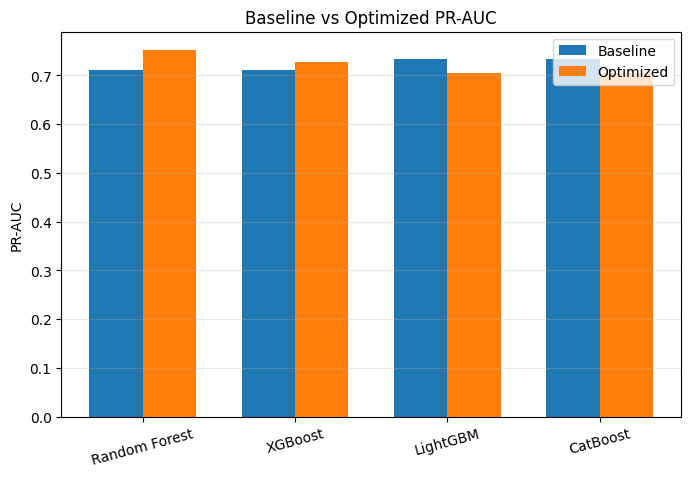

In [104]:
import matplotlib.pyplot as plt
import numpy as np

models = comparison["Model"]

baseline = comparison["PR_AUC_Baseline"]
optimized = comparison["PR_AUC_Optimized"]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, baseline, width,
        label="Baseline")

plt.bar(x+width/2, optimized, width,
        label="Optimized")

plt.xticks(x, models, rotation=15)

plt.ylabel("PR-AUC")
plt.title("Baseline vs Optimized PR-AUC")

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

In [105]:
optimized_models.keys()

dict_keys(['Optimized Random Forest', 'Optimized XGBoost', 'Optimized LightGBM', 'Optimized CatBoost'])

In [106]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

overfitting_results = []

for name, model in optimized_models.items():

    # Train predictions
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    # Test predictions
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    overfitting_results.append({

        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),

        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),

        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),

        "Train ROC_AUC": roc_auc_score(y_train, y_train_prob),
        "Test ROC_AUC": roc_auc_score(y_test, y_test_prob),

        "Train PR_AUC": average_precision_score(y_train, y_train_prob),
        "Test PR_AUC": average_precision_score(y_test, y_test_prob)

    })

overfit_df = pd.DataFrame(overfitting_results)

overfit_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC_AUC,Test ROC_AUC,Train PR_AUC,Test PR_AUC
0,Optimized Random Forest,0.997875,0.970273,0.995768,0.626667,1.0,0.854545,0.997879,0.723077,0.999999,0.987512,0.999999,0.752239
1,Optimized XGBoost,1.000000,0.965318,1.000000,0.586667,1.0,0.800000,1.000000,0.676923,1.000000,0.986631,1.000000,0.726728
2,Optimized LightGBM,1.000000,0.972750,1.000000,0.644737,1.0,0.890909,1.000000,0.748092,1.000000,0.986364,1.000000,0.705199
3,Optimized CatBoost,1.000000,0.960363,1.000000,0.538462,1.0,0.890909,1.000000,0.671233,1.000000,0.985735,1.000000,0.705428


The optimized ensemble models achieved near-perfect performance on the SMOTENC-balanced training data, indicating a high degree of fit. However, evaluation on the unseen imbalanced test set yielded consistently strong predictive performance (PR-AUC ≈ 0.70–0.75), suggesting moderate overfitting but acceptable generalization.

> The use of Stratified Cross-Validation during hyperparameter tuning and evaluation on an untouched test set helps reduce the risk of overly optimistic performance estimates.


---



## Feature Importance

Among the optimized ensemble models, *Random Forest* was selected as the final Early Warning System due to its highest Precision–Recall AUC (0.752), indicating superior performance in distinguishing financially distressed firms under class imbalance.

The model also achieved a strong balance between precision (0.627) and recall (0.855), making it well suited for identifying distressed companies while maintaining a reasonable false-positive rate.

In [107]:
final_model = optimized_models["Optimized Random Forest"]

In [108]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,Feature,Importance
0,InterestCoverage,0.261987
1,ROA,0.129618
2,NetProfit,0.128960
3,OperatingProfit,0.078743
4,EquityRatio,0.062129
5,CFOtoAssets,0.061892
6,CFO,0.050424
7,DebtAssets,0.043576
8,FCF,0.027041
9,Interest,0.023520


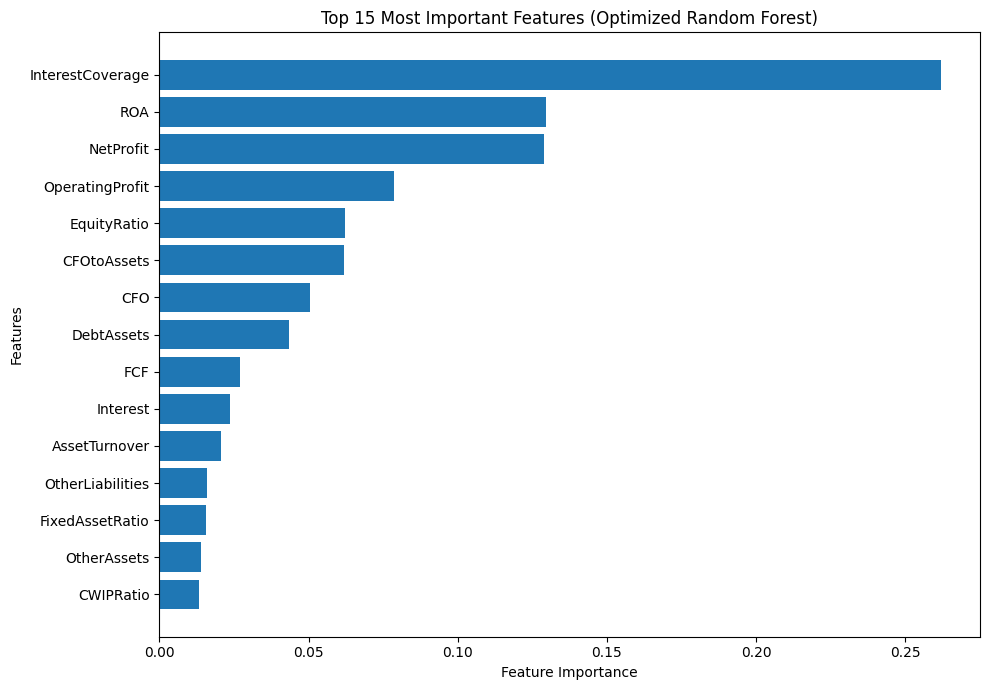

In [109]:
import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:top_n][::-1],
    importance_df["Importance"][:top_n][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Most Important Features (Optimized Random Forest)")

plt.tight_layout()
plt.show()

*The optimized Random Forest model identified Interest Coverage, ROA, Net Profit, Operating Profit, Equity Ratio, and Cash Flow from Operations as the most influential predictors of future financial distress.*

These variables are consistent with established indicators of corporate financial health, suggesting that profitability, debt-servicing ability, and operational cash generation play a central role in distinguishing distressed firms.

In [110]:
X_train_no_ic = X_train.drop(columns=["InterestCoverage"])
X_test_no_ic = X_test.drop(columns=["InterestCoverage"])

rf = RandomForestClassifier(
    **best_params["Random Forest"],
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_no_ic, y_train)

y_prob = rf.predict_proba(X_test_no_ic)[:,1]

print("PR-AUC:",
      average_precision_score(y_test, y_prob))

PR-AUC: 0.7161140458664544


> Although Interest Coverage contributes to the rule-based construction of the distress label, an ablation analysis showed that removing the variable reduced PR-AUC from 0.752 to 0.716, indicating that the model relies on a broad set of financial indicators rather than a single dominant feature.

Although Interest Coverage was used to derive Current Distrees label from which Future Distress was created, there is no direct leakage but there is an indirect dependence.

* So Random Forest discovers

    > Companies with poor Interest Coverage today are likely to become distressed next year.

## SHAP

#### SHAP Explainability

To improve the interpretability of the proposed Early Warning System, SHAP (SHapley Additive exPlanations) was employed. Unlike traditional feature importance, SHAP quantifies both the magnitude and direction of each feature's contribution to the prediction of financial distress, providing a more transparent explanation of model behavior.

In [111]:
!pip install shap -q

In [112]:
import shap

shap.initjs()

In [113]:
# Final selected model
final_model = optimized_models["Optimized Random Forest"]

# Tree SHAP Explainer
explainer = shap.TreeExplainer(final_model)

In [114]:
shap_values = explainer.shap_values(X_test)

In [115]:
print(type(shap_values))

<class 'numpy.ndarray'>


* SHAP Global Importance

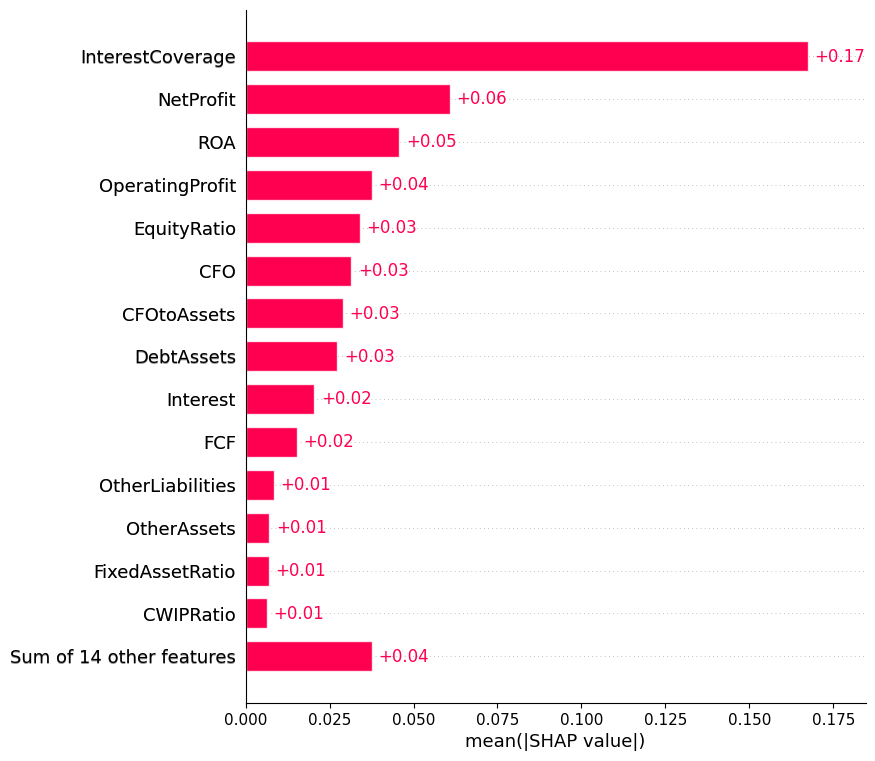

In [116]:
plt.figure(figsize=(10,7))

shap.plots.bar(
    shap.Explanation(
        values=shap_values[:,:,1],
        base_values=explainer.expected_value[1],
        data=X_test.values,
        feature_names=X_test.columns
    ),
    max_display=15
)

> The SHAP feature importance plot ranks variables according to their average contribution to the model's predictions across all observations.

>Consistent with the Random Forest feature importance analysis, *Interest Coverage emerged as the most influential predictor of future financial distress*, followed by Net Profit, ROA, Operating Profit, Equity Ratio, Cash Flow from Operations (CFO), CFO-to-Assets ratio, and Debt-to-Assets ratio.

* SHAP Beeswarm Plot

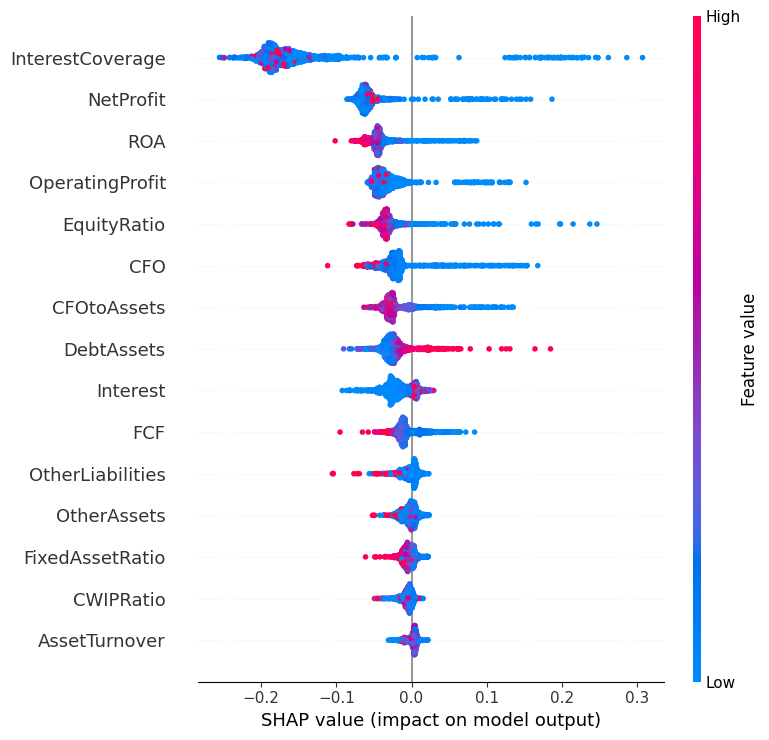

In [117]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    max_display=15
)

    Red = High feature value
    Blue = Low feature value
    Right (+ SHAP) → increases predicted distress probability.
    Left (− SHAP) → decreases predicted distress probability.

>* The distribution of SHAP values indicates that low Interest Coverage, low Net Profit, low ROA, low Operating Profit, low CFO, and low Equity Ratio generally increase the predicted probability of financial distress, whereas higher values of these variables reduce the predicted risk.*

>*Conversely, higher Debt-to-Assets ratios contribute positively toward distress prediction.*

If we take Interest Coverage as example,

    Low Interest Coverage (blue) → appears on the right → increases predicted distress.
    High Interest Coverage (red) → appears on the left → reduces predicted distress.

This matches financial intuition.

Companies that struggle to cover their interest expenses are much more likely to experience financial distress.


---



### Threshold Optimization

#### Threshold Optimization Explainability

The optimized Random Forest model predicts the probability of future financial distress rather than directly assigning class labels. Instead of using the default classification threshold of 0.50, threshold optimization was performed to identify the probability cutoff that maximizes the F1-score.

>Since the dataset is imbalanced, the F1-score provides an appropriate balance between Precision and Recall, resulting in a more effective decision threshold for the proposed Early Warning System.

**note : PR-AUC is independent of threshold.**

In [118]:
from sklearn.metrics import precision_recall_curve

# Probability of financial distress
y_prob = final_model.predict_proba(X_test)[:, 1]

In [119]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

In [120]:
import numpy as np
import pandas as pd

# Ignore last precision/recall value (no corresponding threshold)
f1_scores = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-10
)

threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1],
    "F1": f1_scores
})

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.000000,0.045417,1.0,0.086888
1,0.000006,0.047496,1.0,0.090684
2,0.000046,0.047743,1.0,0.091135
3,0.000051,0.048246,1.0,0.092050
4,0.000052,0.048845,1.0,0.093141


In [121]:
# Optimal Threshold

best_idx = threshold_df["F1"].idxmax()

best_threshold = threshold_df.loc[best_idx, "Threshold"]

print(f"Optimal Threshold : {best_threshold:.3f}")
print()

threshold_df.loc[[best_idx]]

Optimal Threshold : 0.535



,Threshold,Precision,Recall,F1
826,0.535015,0.635135,0.854545,0.728682


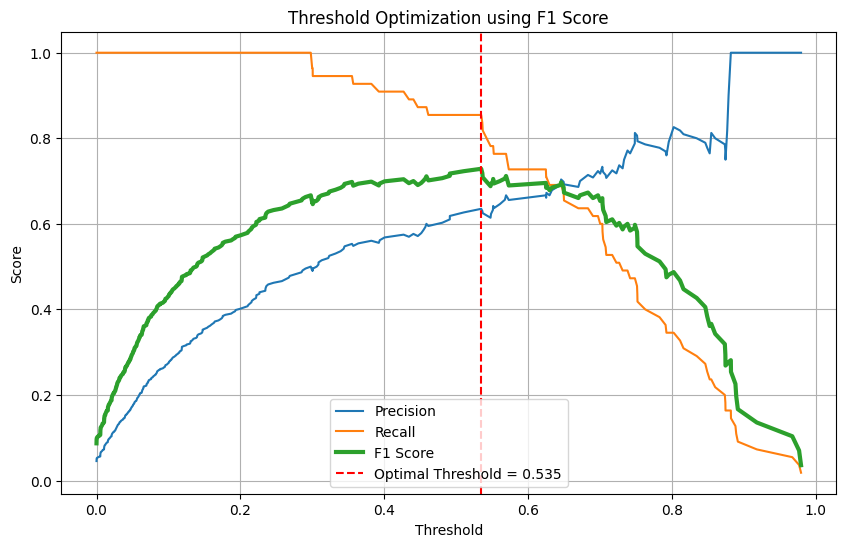

In [122]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    linewidth=3,
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Optimal Threshold = {best_threshold:.3f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization using F1 Score")
plt.legend()

plt.grid(True)

plt.show()

The threshold optimization plot illustrates how Precision, Recall, and F1-score vary across different probability thresholds for the optimized Random Forest model. The maximum F1-score was achieved at a threshold of 0.535, which was selected as the optimal decision boundary for classifying firms as financially distressed or healthy.

    The Threshold of 0.535 means:

  >A company is classified as financially distressed only if its predicted probability of future distress is at least 53.5%. Otherwise, it is classified as healthy.

  * *It suggests that a slightly stricter cutoff (53.5%) provides a better balance between correctly identifying distressed firms (Recall) and avoiding false alarms (Precision).*



---



#### **Business Application :**

> A company is flagged for immediate credit review ONLY IF the ensemble model determines there is at least a 53.5% probability of financial distress occurring within the next 12 months.

> Any probability below 53.5% is absorbed as acceptable operational risk, and the company remains classified as healthy.

## *Final Model*

In [123]:
# Generate probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# Generate predictions using optimized threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

final_summary = pd.DataFrame({

    "Criterion": [
        "Selected Model",
        "Hyperparameter Tuning",
        "Cross Validation",
        "Primary Evaluation Metric",
        "Optimal Threshold",
        "Final PR-AUC",
        "Final ROC-AUC",
        "Final F1 Score"
    ],

    "Value": [
        "Optimized Random Forest",
        "Optuna",
        "5-Fold Stratified",
        "PR-AUC",
        round(best_threshold, 3),
        round(average_precision_score(y_test, y_prob), 3),
        round(roc_auc_score(y_test, y_prob), 3),
        round(f1_score(y_test, y_pred_opt), 3)
    ]

})

final_summary

,Criterion,Value
0,Selected Model,Optimized Random Forest
1,Hyperparameter Tuning,Optuna
2,Cross Validation,5-Fold Stratified
3,Primary Evaluation Metric,PR-AUC
4,Optimal Threshold,0.535
5,Final PR-AUC,0.752
6,Final ROC-AUC,0.988
7,Final F1 Score,0.729


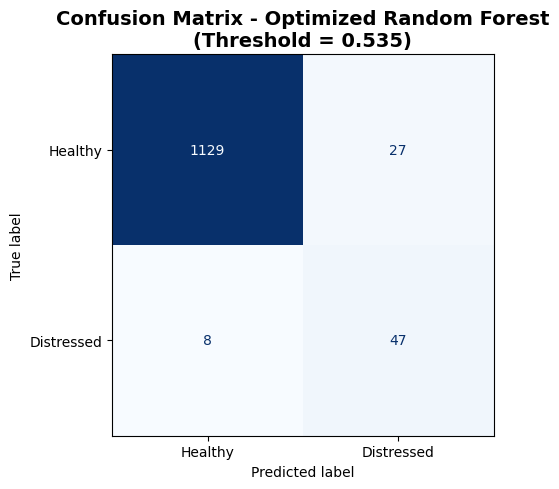

True Negatives : 1129
False Positives: 27
False Negatives: 8
True Positives : 47


In [124]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calculate the confusion matrix using y_test and y_pred_opt
cm = confusion_matrix(y_test, y_pred_opt)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Distressed"]
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title(
    "Confusion Matrix - Optimized Random Forest\n(Threshold = 0.535)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

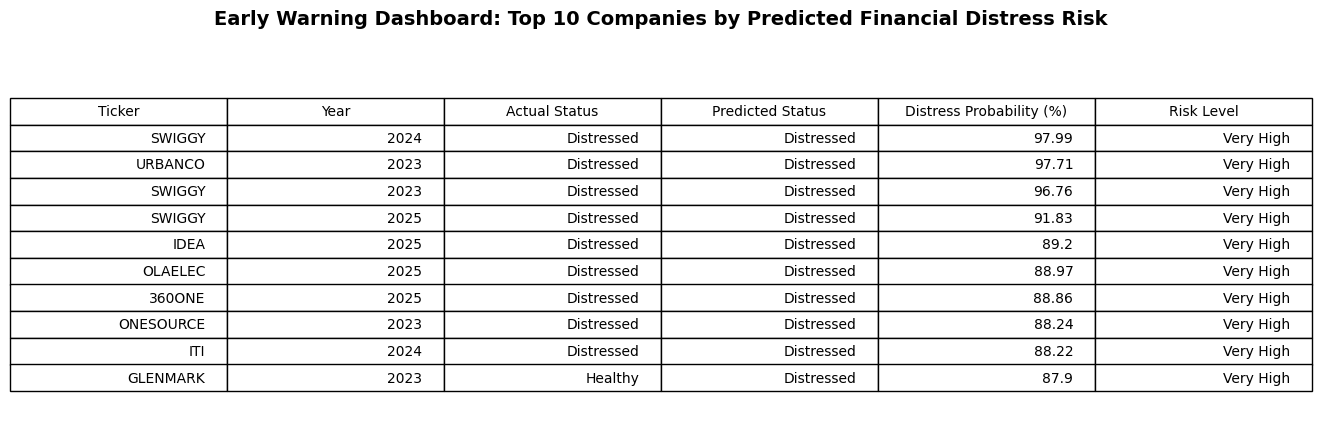

In [125]:
# Create dashboard
dashboard = pd.DataFrame({

    "Ticker": df.loc[X_test.index, "Ticker"],
    "Year": df.loc[X_test.index, "Year"],
    "Actual Status": y_test.values,
    "Predicted Probability": y_prob,
    "Predicted Status": y_pred_opt

})

# Convert labels to text
dashboard["Actual Status"] = dashboard["Actual Status"].map({
    0: "Healthy",
    1: "Distressed"
})

dashboard["Predicted Status"] = dashboard["Predicted Status"].map({
    0: "Healthy",
    1: "Distressed"
})

# Convert probability into percentage
dashboard["Distress Probability (%)"] = (
    dashboard["Predicted Probability"] * 100
).round(2)

dashboard.drop(columns="Predicted Probability", inplace=True)

# Risk categories
def risk_level(prob):

    if prob >= 80:
        return "Very High"

    elif prob >= 60:
        return "High"

    elif prob >= 40:
        return "Moderate"

    else:
        return "Low"

dashboard["Risk Level"] = dashboard["Distress Probability (%)"].apply(risk_level)

# Rank by probability
dashboard = dashboard.sort_values(
    by="Distress Probability (%)",
    ascending=False
)

dashboard.reset_index(drop=True, inplace=True)
dashboard.index += 1
dashboard.index.name = "Rank"

dashboard.head(10)

import matplotlib.pyplot as plt

# Top 10 companies
display_df = dashboard.head(10)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.title(
    "Early Warning Dashboard: Top 10 Companies by Predicted Financial Distress Risk",
    fontsize=14,
    weight="bold",
    pad=20
)

plt.show()

# Threshold : 0.535015

#### The proposed Early Warning System is designed to be updated annually.

 As new financial statements become available, the trained model can estimate the probability of financial distress for the subsequent year, enabling continuous risk monitoring of publicly listed Indian companies.



---



* ## *Estimating the probability of financial distress in 2026 based on the latest available financial information.*

In [126]:
df["Year"].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2015, 2016, 2017,
       2011, 2012, 2014, 2005, 2006, 2007, 2008, 2009, 2013, 2010])

In [127]:
# Latest available financial statements
df_2025 = df[df["Year"] == 2025].copy()

print("Number of companies:", len(df_2025))
df_2025.head()

Number of companies: 405


,Ticker,Year,Borrowings,CFO,CWIP,Depreciation,EquityCapital,FCF,FixedAssets,Interest,...,OperatingMargin,NetMargin,DebtEquity,EquityRatio,CFOtoAssets,FCFtoAssets,AssetTurnover,FixedAssetRatio,CWIPRatio,InvestmentRatio
7,360ONE,2025,11160.0,-2411.0,88.0,41.0,39.0,-2458.0,1281.0,296.0,...,0.613887,0.276884,1.579618,0.357396,-0.121965,-0.124342,0.059743,0.064802,0.004452,0.384864
24,AARTIIND,2025,3848.0,1242.0,1454.0,121.0,181.0,-137.0,6377.0,69.0,...,0.138481,0.057377,0.686530,0.504319,0.111751,-0.012327,0.208566,0.573781,0.130826,0.004319
30,ABB,2025,85.0,1220.0,116.0,39.0,42.0,980.0,1195.0,5.0,...,0.153959,0.126497,0.010847,0.574571,0.089456,0.071858,0.250990,0.087623,0.008506,0.000147
36,ABDL,2025,905.0,-678.0,19.0,18.0,56.0,-806.0,749.0,26.0,...,0.135593,0.063809,0.586520,0.436616,-0.191851,-0.228070,0.283814,0.211941,0.005376,0.000000
43,ABFRL,2025,5017.0,1644.0,181.0,350.0,1220.0,1051.0,9417.0,132.0,...,0.127211,-0.057709,0.736494,0.415518,0.100281,0.064109,0.144809,0.574417,0.011041,0.106685


In [128]:
X = pd.get_dummies(df, columns=["Sector"], drop_first=True)

In [129]:
print(X_train.columns.tolist())

['NetProfit', 'OperatingProfit', 'ROA', 'CFO', 'FCF', 'CFOtoAssets', 'Interest', 'DebtAssets', 'EquityRatio', 'InterestCoverage', 'FixedAssetRatio', 'CWIPRatio', 'Depreciation', 'OtherAssets', 'Sales', 'AssetTurnover', 'OtherLiabilities', 'Year', 'Sector_Communication Services', 'Sector_Consumer Cyclical', 'Sector_Consumer Defensive', 'Sector_Energy', 'Sector_Financial Services', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Real Estate', 'Sector_Technology', 'Sector_Utilities']


In [130]:
print(df.columns.tolist())

['Ticker', 'Year', 'Borrowings', 'CFO', 'CWIP', 'Depreciation', 'EquityCapital', 'FCF', 'FixedAssets', 'Interest', 'Investments', 'NetProfit', 'OperatingProfit', 'OtherAssets', 'OtherLiabilities', 'PBT', 'Reserves', 'Sales', 'TotalAssets', 'TotalLiabilities', 'Equity', 'Sector', 'DebtAssets', 'SectorThreshold', 'InterestCoverage', 'CurrentDistress', 'FutureDistress', 'ROA', 'ROE', 'OperatingMargin', 'NetMargin', 'DebtEquity', 'EquityRatio', 'CFOtoAssets', 'FCFtoAssets', 'AssetTurnover', 'FixedAssetRatio', 'CWIPRatio', 'InvestmentRatio']


In [131]:
df_2025 = pd.get_dummies(
    df_2025,
    columns=["Sector"],
    drop_first=True
)

In [132]:
# Add any missing dummy columns
for col in X_train.columns:
    if col not in df_2025.columns:
        df_2025[col] = 0

In [133]:
X_2025 = df_2025[X_train.columns]

In [134]:
print(scaler.feature_names_in_)

['NetProfit' 'OperatingProfit' 'ROA' 'CFO' 'FCF' 'CFOtoAssets' 'Interest'
 'DebtAssets' 'EquityRatio' 'InterestCoverage' 'FixedAssetRatio'
 'CWIPRatio' 'Depreciation' 'OtherAssets' 'Sales' 'AssetTurnover'
 'OtherLiabilities']


In [135]:
num_cols = list(scaler.feature_names_in_)

X_num = pd.DataFrame(
    scaler.transform(df_2025[num_cols]),
    columns=num_cols,
    index=df_2025.index
)

other_cols = [
    "Year",
    "Sector_Communication Services",
    "Sector_Consumer Cyclical",
    "Sector_Consumer Defensive",
    "Sector_Energy",
    "Sector_Financial Services",
    "Sector_Healthcare",
    "Sector_Industrials",
    "Sector_Real Estate",
    "Sector_Technology",
    "Sector_Utilities"
]

X_other = df_2025[other_cols]

In [136]:
X_2025 = pd.concat([X_num, X_other], axis=1)

In [137]:
X_2025 = X_2025[X_train.columns]

In [138]:
prob_2026 = final_model.predict_proba(X_2025)[:, 1]

pred_2026 = (prob_2026 >= best_threshold).astype(int)

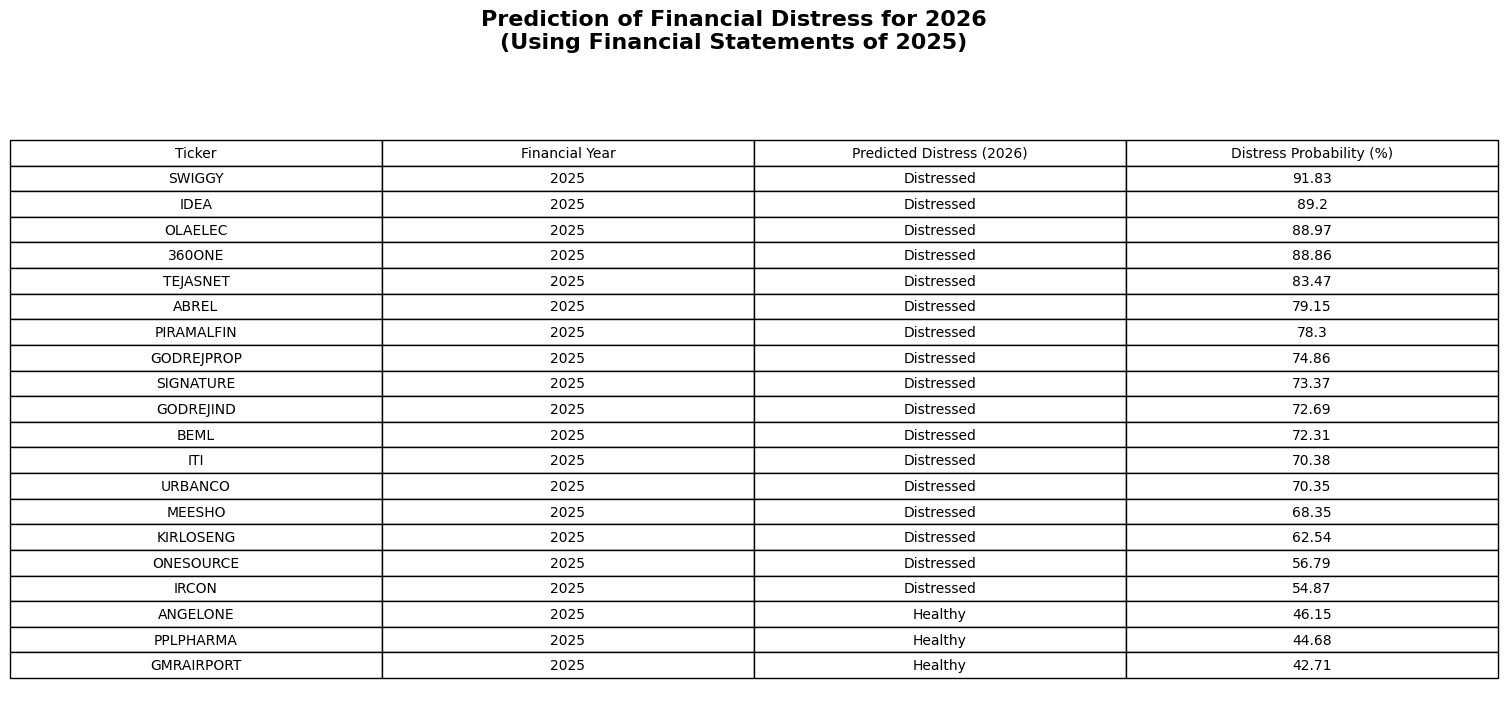

In [139]:
prediction_2026 = pd.DataFrame({

    "Ticker": df_2025["Ticker"],
    "Financial Year": 2025,
    "Predicted Distress (2026)": pred_2026,
    "Distress Probability (%)": (prob_2026 * 100).round(2)

})

prediction_2026["Predicted Distress (2026)"] = (
    prediction_2026["Predicted Distress (2026)"]
    .map({
        0: "Healthy",
        1: "Distressed"
    })
)

prediction_2026 = prediction_2026.sort_values(
    "Distress Probability (%)",
    ascending=False
)



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")

table = ax.table(
    cellText=prediction_2026.head(20).values,
    colLabels=prediction_2026.head(20).columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

fig.suptitle(
    "Prediction of Financial Distress for 2026\n(Using Financial Statements of 2025)",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.subplots_adjust(top=0.85)

plt.show()


# Limitations

While the proposed Early Warning System demonstrates strong predictive performance, several limitations should be acknowledged:

1. The target variable was constructed using rule-based accounting indicators rather than actual bankruptcy or insolvency events, which may not capture all forms of financial distress.

2. The dataset consists only of Indian publicly listed companies and may not generalize to private firms or companies operating in other countries.

3. Although SMOTENC effectively addressed class imbalance during model training, synthetic observations may not perfectly represent the complexity of real distressed firms.

4. The Random Forest model does not explicitly model temporal dependencies between consecutive financial years. Future work could explore time-series or sequential learning approaches.

5. The deployment example for 2026 represents forward-looking forecasts based on 2025 financial statements. Since actual 2026 outcomes are unavailable, these predictions have not yet been externally validated.

# Future Work

The proposed framework can be extended in several directions:

- Incorporate macroeconomic indicators such as GDP growth, inflation, and interest rates to capture broader economic conditions.

- Integrate market-based variables including stock returns, volatility, and market capitalization.

- Explore advanced temporal models such as LSTM, Temporal Fusion Transformers, or survival analysis to better capture the evolution of financial distress over time.

- Apply probability calibration techniques to improve the interpretation of predicted distress probabilities.

- Develop an automated dashboard that updates annually as new financial statements become available, enabling continuous monitoring of listed companies.

# Conclusion

This study developed an Early Warning System for predicting the future financial distress of Indian publicly listed companies using accounting-based financial indicators and machine learning techniques. Following comprehensive data preprocessing, feature engineering, class imbalance handling using SMOTENC, and extensive model evaluation, the Optimized Random Forest model was selected as the final prediction model based on its superior Precision–Recall AUC and overall predictive performance.

Model interpretability was enhanced through SHAP analysis, providing insights into the financial variables most strongly associated with distress risk. Threshold optimization further improved the balance between Precision and Recall, while the deployment example demonstrated how the proposed framework can be applied to estimate future financial distress using the latest available financial statements.

Overall, the proposed Early Warning System provides a practical decision-support tool for investors, lenders, regulators, and corporate stakeholders by facilitating the early identification of financially vulnerable firms and enabling timely risk management.